# Chapter 10 - Quantization Techniques for Deep Learning and Generative Models

## Learning Outcomes

By the end of this chapter, the learner should be able to:

1. Explain the motivation for quantization in terms of memory reduction, faster inference, lower bandwidth, lower energy use, and practical deployment.
2. Distinguish clearly between pre-quantization, during-training quantization, and post-training quantization.
3. Interpret the standard quantization formula and explain the meanings of scale, integer code, levels, range, and zero-point.
4. Explain the central tradeoff between quantization resolution and representable range, including rounding error and clipping error.
5. Compare per-tensor, per-channel, and group-wise quantization, and discuss when each is useful.
6. Explain the principles of quantization-aware training, including fake quantization, the straight-through estimator, and learned quantization parameters such as clipping thresholds and step sizes.
7. Describe major post-training quantization ideas, including calibration, reconstruction, second-order sensitivity, and compensation-based methods.
8. Explain the roles of curvature and the Hessian in quantization, and relate them to GPTQ-style second-order methods.
9. Describe modern transformer and LLM quantization methods such as SmoothQuant, AWQ, OmniQuant, I-BERT, and QLoRA at a conceptual level.
10. Implement and interpret practical quantization experiments in PyTorch, including comparisons of accuracy, compression, and latency on benchmark data such as MNIST.

## License

**Text, figures, and explanations:**  
© 2026 Imran Zualkernan. Licensed under **CC BY 4.0**.

**Code cells:**  
© 2026 Imran Zualkernan. Licensed under the **MIT License**.

You are free to reuse, modify, and redistribute with attribution.

# Part I. Problem formulation and historical timeline

## Why do quantization?

Modern neural networks are often trained in FP32, BF16, or FP16, but deployment is limited by three coupled bottlenecks:

- **Memory footprint**
- **Memory bandwidth**
- **Arithmetic throughput**

Suppose a model has parameters $W = \{W_\ell\}_{\ell=1}^L$.

If a layer has $n_\ell$ scalar weights stored in $b$ bits, then the storage for that layer is

$$
M_\ell = n_\ell b \text{ bits}.
$$

Hence the total parameter storage is

$$
M_{\mathrm{total}} = \sum_{\ell=1}^{L} n_\ell b_\ell.
$$

This equation is simple but central. It says that model compression through quantization is obtained by reducing $b_\ell$, the number of bits per parameter.

If the baseline is FP32 and we move to INT8, then, ideally, parameter storage drops by a factor of

$$
\frac{32}{8} = 4.
$$

If we move to INT4, the ideal parameter-only compression factor is

$$
\frac{32}{4} = 8.
$$

But quantization is **not just compression**. It also changes the arithmetic path. On hardware with fast integer units, matrix multiplication with INT8 or INT4 can reduce latency and energy, provided that:

1. the runtime truly uses quantized kernels,
2. the dequantization overhead is controlled,
3. activations are quantized in a hardware-compatible way,
4. outliers do not force many values back to high precision.


## The quantization problem as constrained approximation

Let $f(x; W)$ be a trained network and let $Q(W)$ denote the quantized parameters.

The basic approximation problem is

$$
Q(W) = \arg\min_{\widehat{W} \in \mathcal{Q}} \mathcal{D}(W, \widehat{W}),
$$

where $\mathcal{Q}$ is the discrete set of representable quantized values and $\mathcal{D}$ is some distortion measure.

A first choice is simple Euclidean distortion:

$$
\mathcal{D}(W, \widehat{W}) = \|W - \widehat{W}\|_2^2.
$$

However, this is often too naive. What matters is not only parameter error, but the change in the task loss. We want the change in loss to be zero, or ensure that the quantization has no impact on the loss:

$$
\Delta \mathcal{L} \approx \mathcal{L}(\widehat{W}) - \mathcal{L}(W).
$$

A second-order Taylor expansion gives

$$
\mathcal{L}(\widehat{W}) \approx \mathcal{L}(W)
+ \nabla \mathcal{L}(W)^\top (\widehat{W} - W)
+ \frac{1}{2} (\widehat{W} - W)^\top H (\widehat{W} - W),
$$

where $H$ is the Hessian of the loss with respect to the weights.

At a local optimum after training, the gradient term is often small, so the dominant error model becomes

$$
\Delta \mathcal{L} \approx \frac{1}{2} (\widehat{W} - W)^\top H (\widehat{W} - W).
$$

This equation is the conceptual bridge from **simple rounding** to **second-order PTQ methods** such as OBC and GPTQ.


**Deriving using the Taylor Series**

$$
\mathcal{L}(\widehat{W}) \approx \mathcal{L}(W)
+ \nabla \mathcal{L}(W)^\top (\widehat{W} - W)
+ \frac{1}{2} (\widehat{W} - W)^\top H(W) (\widehat{W} - W),
$$

start from the multivariable Taylor series.

For a twice-differentiable scalar function $f:\mathbb{R}^d \to \mathbb{R}$, the second-order Taylor expansion around a point $a$ is

$$
f(a+h)
\approx
f(a)
+
\nabla f(a)^\top h
+
\frac{1}{2} h^\top H(a)\, h,
$$

where:

- $h$ is a small perturbation,
- $\nabla f(a)$ is the gradient,
- $H(a)$ is the Hessian.

Now set

$$
f = \mathcal{L},
\qquad
a = W,
\qquad
h = \widehat{W} - W.
$$

Since

$$
\widehat{W} = W + (\widehat{W} - W),
$$

we can write

$$
\mathcal{L}(\widehat{W}) = \mathcal{L}(W+h).
$$

Applying the Taylor formula gives

$$
\mathcal{L}(W+h)
\approx
\mathcal{L}(W)
+
\nabla \mathcal{L}(W)^\top h
+
\frac{1}{2} h^\top H(W)\, h.
$$

Finally, substitute back

$$
h = \widehat{W} - W.
$$

This yields

$$
\mathcal{L}(\widehat{W}) \approx \mathcal{L}(W)
+ \nabla \mathcal{L}(W)^\top (\widehat{W} - W)
+ \frac{1}{2} (\widehat{W} - W)^\top H(W) (\widehat{W} - W).
$$

So this formula is simply the second-order multivariable Taylor expansion of the loss around the full-precision weights $W$, with perturbation equal to the quantization error $\widehat{W} - W$.

## Historical timeline

A compact research timeline is:

- **2015 to 2016:** binary and ternary ideas become influential, including BinaryConnect and XNOR-Net
- **2016 to 2018:** low-bit CNN training becomes more systematic, including DoReFa-Net and PACT
- **2018:** practical 8-bit deployment becomes mainstream with integer arithmetic pipelines and affine quantization formulations
- **2019 to 2020:** learned quantizers and stronger PTQ emerge, such as LSQ and AdaRound
- **2021 onward:** transformers and integer-only transformer inference become central, such as I-BERT
- **2022 onward:** LLM quantization becomes a major field, including LLM.int8(), GPTQ, SmoothQuant, AWQ, OmniQuant, and QLoRA
- **2023 onward:** quantization for diffusion and diffusion transformers becomes active, including Q-Diffusion, PTQD, Q-DiT, and later DiT-specific PTQ methods
- **2025 onward:** quantization for flow matching appears to be emerging but is still much less mature than the LLM and diffusion literature


## Notation guide

This chapter uses a common notation across all three phases: **pre-quantization**, **during-training quantization**, and **post-training quantization**.

### Scalars, vectors, matrices, and tensors

- A scalar is written as $x$, $s$, $\alpha$, or $\Delta$.
- A vector is written in bold lower case, for example $w \in \mathbb{R}^n$.
- A matrix is written in bold upper case, for example $W \in \mathbb{R}^{m \times n}$.
- A tensor is written with an explicit shape when useful, for example $X \in \mathbb{R}^{B \times C \times H \times W}$.

### Frequently used symbols

- $x$: a real-valued scalar, vector, or tensor before quantization.
- $\widehat{x}$: the dequantized reconstruction after quantization.
- $q$: the stored integer tensor.
- $b$: bit-width.
- $q_{\max}$: the largest positive representable integer level. For signed symmetric $b$-bit quantization,
  $$
  q_{\max} = 2^{b-1} - 1.
  $$
- $s$: scale.
- $z$: zero-point in affine quantization.
- $\alpha$: clipping threshold.
- $\Delta$: generic perturbation or step size. In some sections we use $\Delta$ and $s$ almost interchangeably for the quantization interval.
- $W$: model weights.
- $\widehat{W}$: quantized or dequantized weights.
- $e = \widehat{w} - w$: the quantization error after vectorizing the parameters.
- $\mathcal{L}$: the task loss.
- $H$: the Hessian matrix of second derivatives of the loss with respect to a parameter vector.

### Operators and shorthand

- $\mathrm{round}(\cdot)$: round to the nearest integer.
- $\mathrm{clip}(x, a, b)$: clip $x$ into the interval $[a,b]$.
- $\lVert x \rVert_2$: Euclidean norm.
- $\mathbb{E}[\cdot]$: expectation.
- $\arg\min$: the argument that minimizes an objective.
- $\mathrm{diag}(d)$: a diagonal matrix whose diagonal entries come from the vector $d$.
- $\odot$: elementwise multiplication.

### What does $\mathrm{vec}(\cdot)$ mean?

When we write

$$
\Delta \mathcal{L} \approx \frac{1}{2}\,\mathrm{vec}(\Delta W)^\top H\,\mathrm{vec}(\Delta W),
$$

we are turning the matrix $\Delta W$ into one long vector so we can write the second-order loss increase as a standard quadratic form.

In this notebook, we use the same convention as `reshape(-1)` in PyTorch:

$$
\mathrm{vec}\!\left(
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
\right)
=
\begin{bmatrix}
a \\
b \\
c \\
d
\end{bmatrix}.
$$

Some papers use column-major vectorization instead. The specific ordering changes the coordinate representation of $H$, but the basic quadratic idea stays the same as long as the vectorization convention is used consistently.

In [ ]:
W_demo = [[1.0, 2.0],
          [3.0, 4.0]]

vec_demo = [1.0, 2.0, 3.0, 4.0]
diag_demo = [[0.5, 0.0],
             [0.0, 2.0]]
recovered_demo = [[vec_demo[0], vec_demo[1]],
                  [vec_demo[2], vec_demo[3]]]

{
    "W": W_demo,
    "vec(W)": vec_demo,
    "diag([0.5, 2.0])": diag_demo,
    "reshape(vec(W), 2, 2)": recovered_demo,
}

## Three Phases of Quantization

Quantization studies how to replace high-precision numerical representations with lower-precision ones while preserving the functional behavior of a model as much as possible. The motivation is both practical and scientific. Practically, lower precision reduces memory footprint, bandwidth, energy consumption, and inference latency. Scientifically, it forces us to ask which numerical details are essential to model performance and which can be coarsened without significant harm.

At a high level, quantization can be understood as introducing a mapping from a continuous or high-resolution numerical space to a discrete set of representable levels. This mapping inevitably introduces approximation error. The central problem is therefore not simply how to quantize, but how to manage the tradeoff between numerical efficiency and task performance.

A useful conceptual framework is to divide the subject into three phases:

1. **Pre-quantization**, where we analyze and prepare the model before low-precision constraints are imposed.
2. **During-training quantization**, where low-precision effects are incorporated into the optimization process.
3. **Post-training quantization**, where an already trained model is converted to low precision with minimal additional learning.

These three phases correspond to three different points in the model lifecycle at which we may choose to address the same fundamental challenge:

$$
\text{How can we reduce precision while preserving accuracy, stability, and deployability?}
$$

They should not be viewed as unrelated topics. Rather, they are three complementary perspectives on the same problem. Pre-quantization focuses on **understanding and preparation**. During-training quantization focuses on **adaptation through learning**. Post-training quantization focuses on **approximation and efficient conversion**.

### Pre-Quantization

We begin with pre-quantization because it provides the conceptual and mathematical foundation for everything that follows. Before discussing training-time or post-training procedures, we must understand what makes a tensor easy or difficult to quantize, how quantization error arises, how dynamic range and outliers affect representability, and why some layers or channels are more sensitive than others. This first part is therefore about the geometry and statistics of quantization: how we represent numbers, where errors come from, and how the structure of the model influences later design choices.

### During-Training Quantization

Once the numerical challenges are clear, the next question is whether the model can learn to become robust to them. This motivates the second phase, during-training quantization. Here, quantization is no longer treated as a passive compression step applied at the end. Instead, it becomes part of the optimization process itself. The model is trained or fine-tuned in the presence of low-precision effects so that its parameters adapt to rounding, clipping, and reduced numerical resolution. This section therefore connects quantization to learning dynamics, gradient-based optimization, and robustness under constrained arithmetic.

### Post-Training Quantization

Finally, we consider the setting in which a high-quality full-precision model already exists and retraining is undesirable or infeasible. In this regime, quantization becomes a problem of approximation under limited freedom. We must decide how to compress the model while preserving the computations that matter most. This leads naturally to calibration, reconstruction, sensitivity analysis, and second-order reasoning. Post-training quantization is especially important in modern large-scale deployment, where the dominant question is not how to train a model from scratch, but how to convert a pretrained model into an efficient low-precision system with minimal loss in quality.

### A Unifying Perspective

Across all three phases, the same core tension remains:

$$
\text{lower precision} \quad \Longleftrightarrow \quad \text{greater efficiency but greater approximation risk}
$$

The field of quantization can therefore be read as a sequence of increasingly refined answers to one question:

$$
\text{Where, when, and how should we handle the error introduced by discrete low-precision representations?}
$$

- In **pre-quantization**, we try to understand and anticipate the error.
- In **during-training quantization**, we train the model to tolerate and compensate for the error.
- In **post-training quantization**, we minimize the damage after training has already been completed.

This three-phase framework gives a coherent structure to the subject and helps relate the many methods in the literature to a single underlying objective: building models that remain accurate even when numerical precision is severely constrained.

## How the methods are related

This chapter is organized around **three phases**, but they all revolve around the same core quantizer that takes an original parameter (say weight)  $x$, scales it using $s$, uses an optional offset $z$ and ensures that the resulting quantized quantity $q$ is within the physical limits of $q_{\min}$ and $q_{\max}$

$$
q = \mathrm{clip}\!\left(\mathrm{round}\!\left(\frac{x}{s}\right) + z,\; q_{\min},\; q_{\max}\right),
\qquad
\widehat{x} = s (q - z).
$$

The difference is **when** and **how** we choose or optimize the quantization parameters.

$x=10$ and $s=2.5$

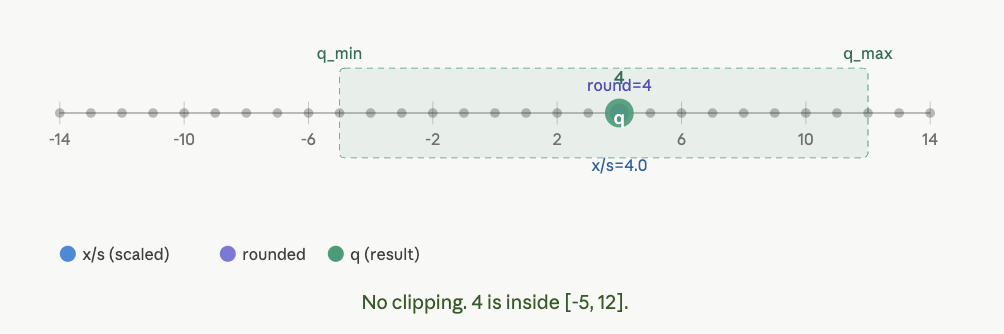

$x=10$ and $s=0.25$

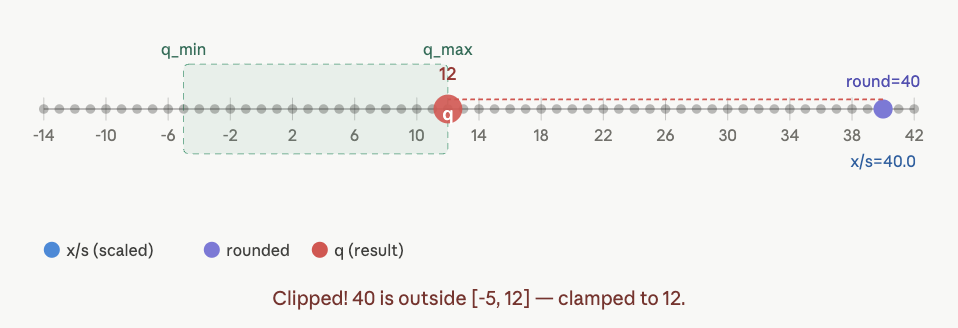

### Pre-quantization

Pre-quantization asks:

- Which layers are sensitive?
- Which bit-width should each layer receive?
- What range, clipping threshold, or calibration data should we use?

Typical tools include observers, calibration, activation histograms, clipping search, sensitivity analysis, and Hessian-inspired diagnostics.

### During-training quantization

During-training quantization keeps quantization inside the optimization problem itself. Rather than training a fully floating-point network and quantizing it only afterward, we train the network while its layer weights and layer activations are quantized during the forward pass.

Let:

$$
W_\ell = \text{weight tensor of layer } \ell
$$

and

$$
a_\ell = \text{activation tensor produced at layer } \ell.
$$

Then a more explicit quantization-aware training objective is:

$$
\min_{\{W_\ell\},\,\{\theta_\ell^{(W)},\theta_\ell^{(a)}\}}
\;
\mathcal{L}\!\left(
f\!\left(
x;\,
\{Q_W(W_\ell;\theta_\ell^{(W)})\}_{\ell=1}^L,\,
\{Q_a(a_\ell;\theta_\ell^{(a)})\}_{\ell=1}^L
\right)
\right).
$$

Here:

- $W_\ell$ is the weight tensor at layer $\ell$,
- $a_\ell$ is the activation tensor at layer $\ell$,
- $Q_W(\cdot;\theta_\ell^{(W)})$ is the weight quantizer for layer $\ell$,
- $Q_a(\cdot;\theta_\ell^{(a)})$ is the activation quantizer for layer $\ell$,
- $\theta_\ell^{(W)}$ and $\theta_\ell^{(a)}$ are quantization parameters such as scales, clipping thresholds, or learned step sizes,
- $L$ is the number of layers,
- $f(\cdot)$ is the network,
- $\mathcal{L}$ is the training loss.

Conceptually, this means that the model is trained while already experiencing the distortions caused by low-precision arithmetic. The optimization therefore does not merely learn good weights in floating point; it learns weights that continue to work well after quantization of both parameters and intermediate computations.

This broad family includes:

- fake quantization,
- straight-through estimators,
- PACT,
- LSQ,
- binary and ternary training.

So quantization-aware training can be understood as learning a network that is robust to layerwise quantization of both weights and activations.

So QAT can be viewed as **learning a model that is robust to the quantizer**.

### Post-training quantization

Post-training quantization starts from a trained floating-point model $W^\star$ and tries to find a good discrete surrogate without retraining from scratch:

$$
\widehat{W} \approx Q(W^\star).
$$

This family begins with simple round-to-nearest quantization, then becomes more sophisticated:

- **AdaRound** improves the rounding decisions,
- **GPTQ** adds second-order curvature information through a Hessian approximation,
- **SmoothQuant** migrates activation difficulty into the weights by a diagonal rescaling,
- **AWQ** protects salient channels and weights,
- **OmniQuant** jointly tunes several PTQ ingredients.

### Conceptual chain

A useful way to see the field is this:

1. **Uniform quantization** gives the basic integer representation.
2. **Calibration** estimates a good range and scale.
3. **PTQ** applies the quantizer after training.
4. **QAT** uses the same quantizer but learns under its noise.
5. **Second-order PTQ** asks not just how large the error is, but how harmful that error is under the local curvature.
6. **Transformer and generative-model quantization** adapt these ideas to activation outliers, attention, KV caches, timesteps, and iterative denoising or flow updates.

### Why later methods look more complicated

They usually modify one of four ingredients:

- the **grid** of representable values,
- the **scale/clipping** rule,
- the **rounding** rule,
- or the **importance weighting** of the error.

That is why many methods that look very different in the literature are actually variations on the same quantization template.

# Part II. Core mathematical foundations

## Uniform affine quantization

A standard affine quantizer maps a real scalar $x$ to an integer $q$ through a scale $s > 0$ and zero point $z$.

The quantization rule is

$$
q = \mathrm{clip}\Bigl(\mathrm{round}\Bigl(\frac{x}{s}\Bigr) + z,\; q_{\min},\; q_{\max}\Bigr).
$$

The reconstruction rule is

$$
\widehat{x} = s (q - z).
$$

### What each symbol means

- $x$ is the original real value
- $q$ is the quantized integer
- $s$ is the step size or scale
- $z$ is the zero point
- $q_{\min}$ and $q_{\max}$ define the integer range

For signed $b$-bit symmetric quantization we often use

$$
q_{\min} = -(2^{b-1}-1), \qquad q_{\max} = 2^{b-1}-1.
$$

For example, in 8-bit symmetric quantization,

$$
q \in [-127, 127].
$$

If the data are approximately centered around zero, symmetric quantization is often preferable because it simplifies arithmetic and implementation.


## Motivation: the tradeoff between scale and range in quantization

A central design question in quantization is the choice of the **scale**. 

### What the scale controls

The integer code is

$$
q
=
\mathrm{clip}\!\left(
\mathrm{round}\!\left(\frac{x}{s}\right),
q_{\min}, q_{\max}
\right),
$$

so the representable real-valued levels are

$$
\{s q_{\min},\; s(q_{\min}+1),\; \dots,\; s q_{\max}\}.
$$

Thus:

- the distance between neighboring levels is $s$,
- the representable interval is

$$
[s q_{\min},\; s q_{\max}].
$$

So if the bit-width is fixed, then changing $s$ changes **both**:

1. the **resolution** of the grid,
2. the **range** covered by the grid.

This is the core tradeoff.

### Why there is a tradeoff

If $s$ is **small**, then the levels are close together. This gives fine resolution and small rounding error for values inside the range. However, the total range becomes narrow, so large values get clipped.

If $s$ is **large**, then the range becomes wider, so clipping is less likely. However, the levels are farther apart, so rounding error increases.

So the designer must balance two kinds of error:

- **rounding error** from using a coarse grid,
- **clipping error** from not covering enough range.

This is why scale selection is not a trivial detail. It is one of the core numerical choices in quantization.

### A useful way to say it

For a fixed number of bits:

> a smaller scale gives **better precision but smaller range**,
>
> while a larger scale gives **larger range but worse precision**.

### Extreme example 1: very small scale

Suppose we use a signed 2-bit quantizer with integer codes $ q \in \{-2,-1,0,1\}.$

Now choose a very small scale:$s = 0.1.$

Then the representable real values are $\{-0.2,\,-0.1,\,0,\,0.1\}.$

So the quantizer has very fine spacing, since adjacent levels differ by only $0.1.$

This looks good at first, because small values can be represented precisely.

For example, if $x = 0.06,$ then $\frac{x}{s} = \frac{0.06}{0.1} = 0.6,$

so $\mathrm{round}(0.6)=1,$ and therefore $\widehat{x} = 0.1.$ The error is only $|0.06 - 0.1| = 0.04.$

So the resolution is quite good.

However, now consider a larger value:$x = 1.4.$ Then $\frac{x}{s} = \frac{1.4}{0.1} = 14,$ but the largest allowed integer code is only $q_{\max}=1.$

So clipping occurs:$q = 1,$ and hence $\widehat{x} = 0.1.$

This is a terrible approximation, because the true value was 1.4 but the quantizer can only represent up to 0.1 on the positive side.

#### Interpretation of extreme example 1

This is the failure mode of an excessively small scale:

- the grid is very fine,
- but the representable range is far too narrow.

So the quantizer is precise for tiny values but useless for moderate or large ones.

### Extreme example 2: very large scale

Now use the same 2-bit signed integer codes $ q \in \{-2,-1,0,1\},$

but choose a very large scale: $s = 10.$

Then the representable values are $\{-20,\,-10,\,0,\,10\}.$

Now the quantizer covers a much wider range, which means clipping is much less likely.

For example, if $x = 7,$ then $\frac{x}{s} = \frac{7}{10} = 0.7,$ so $\mathrm{round}(0.7)=1,$ and therefore $\widehat{x}=10.$ The quantization error is  $ |7 - 10| = 3.$

That is already quite large.

Now consider a smaller value:$x = 1.$ Then $\frac{x}{s} = \frac{1}{10} = 0.1,$ so $\mathrm{round}(0.1)=0,$ and hence $\widehat{x}=0.
$ The error is $|1 - 0| = 1.$

So even small ordinary values are poorly represented, because the grid is too coarse.

#### Interpretation of extreme example 2

This is the failure mode of an excessively large scale:

- the range is very wide,
- but the levels are too far apart.

So clipping is avoided, but rounding error becomes large almost everywhere.

### The key lesson

These two extremes show why scale selection matters.

- If the scale is too small, the quantizer has high resolution but severe clipping.
- If the scale is too large, the quantizer has wide range but severe rounding error.

Thus the goal is not merely to make the scale small or large. The goal is to choose a scale that balances these two sources of distortion.

In practice, this balance may be chosen by:

- simple calibration rules such as min-max or percentile calibration,
- optimization-based methods such as LSQ,
- learned clipping methods such as PACT,
- reconstruction-based post-training methods.

### Final summary

The scale in a quantizer is doing two jobs at once:

1. it sets the **spacing** between levels,
2. it sets the **real-valued range** that the quantizer can cover.

Because one parameter controls both, quantization always involves a tradeoff between:

$$
\text{precision within the range}
\quad \text{and} \quad
\text{coverage of the range}.
$$

This tradeoff is one of the most fundamental motivations for all subsequent quantization methods.

## Symmetric quantization

In symmetric quantization we set the zero point to zero:

$$
z = 0.
$$

Then

$$
q = \mathrm{clip}\Bigl(\mathrm{round}\Bigl(\frac{x}{s}\Bigr),\; -Q,\; Q\Bigr),
$$

where

$$
Q = 2^{b-1} - 1.
$$

The reconstruction is

$$
\widehat{x} = s q.
$$

A common choice for the scale is

$$
s = \frac{\max |x|}{Q}.
$$

### Interpretation

This formula says: choose the quantization step so that the largest magnitude value just fits inside the integer grid.

The price is that if even a small number of outliers are very large, then $s$ becomes large, the grid gets coarse, and many ordinary values are represented poorly. This is why **clipping**, **per-channel quantization**, and **outlier-aware methods** matter so much.


## Quantization error and clipping

If $x$ is quantized to $\widehat{x}$, then the scalar quantization error is

$$
e = x - \widehat{x}.
$$

A natural distortion objective is mean squared error:

$$
\mathrm{MSE} = \mathbb{E}\bigl[(x - \widehat{x})^2\bigr].
$$

With clipping threshold $\alpha > 0$, we first clip

$$
x_{\mathrm{clip}} = \mathrm{clip}(x, -\alpha, \alpha),
$$

and then quantize $x_{\mathrm{clip}}$.

This introduces a tradeoff:

- If $\alpha$ is too large, then outliers force a coarse scale
- If $\alpha$ is too small, then many values saturate

The total distortion can be viewed as

$$
\mathrm{MSE}_{\mathrm{total}} = \mathrm{MSE}_{\mathrm{round}} + \mathrm{MSE}_{\mathrm{clip}}.
$$

This decomposition is not exact in every implementation, but it is a very useful conceptual picture.


## Per-tensor, per-channel, and group-wise quantization

Let a weight matrix be $W \in \mathbb{R}^{m \times n}$.

### Per-tensor quantization

Use one scale for the whole tensor:

$$
\widehat{W} = s \cdot \mathrm{round}\Bigl(\frac{W}{s}\Bigr).
$$

### Per-channel quantization

Use one scale per output channel:

$$
\widehat{W}_{i,:} = s_i \cdot \mathrm{round}\Bigl(\frac{W_{i,:}}{s_i}\Bigr).
$$

### Group-wise quantization

Partition channels or columns into groups $G_1, \dots, G_K$, and use a separate scale per group:

$$
\widehat{W}_{G_k} = s_k \cdot \mathrm{round}\Bigl(\frac{W_{G_k}}{s_k}\Bigr).
$$

### Why later methods prefer group-wise quantization

In large transformers, different channels often have very different dynamic ranges. Per-tensor quantization is then too crude. Per-channel or group-wise schemes reduce error while remaining hardware-friendly.


## Solved numeric examples for scales, clipping, and granularity

These examples are meant to be worked out on the board in front of students.

### Example 1: symmetric 4-bit quantization

Take $x = [-1.8,\,-0.5,\,0.3,\,1.2].$

With 4-bit signed quantization,$Q = 2^{4-1} - 1 = 7.$

Choose $s = \frac{\max |x|}{Q} = \frac{1.8}{7} = 0.2571.$

Then $q = \mathrm{round}\left(\frac{x}{s}\right) = [-7,\,-2,\,1,\,5].$

Reconstruction gives $\widehat{x} = s q = [-1.800,\,-0.514,\,0.257,\,1.286].$

So the quantization errors are approximately $e = x - \widehat{x} = [0,\;0.014,\;0.043,\;-0.086].$

### Example 2: clipping improves central resolution

Suppose we clip to $\alpha = 1.0.$

Then $x_{\mathrm{clip}} = [-1.0,\,-0.5,\,0.3,\,1.0].$

The new scale becomes $s_{\mathrm{clip}} = \frac{1.0}{7} = 0.1429.$

Now $\widehat{x}_{\mathrm{clip}} = [-1.000,\,-0.571,\,0.286,\,1.000].$

We represented the middle values more accurately, but we accepted saturation on the original outlier $-1.8$.

### Example 3: per-tensor versus per-channel

Let channel A be $ A = [0.10,\,0.20,\,0.15], $ and channel B be $ B = [3.0,\,-2.5,\,2.0]. $

With one 4-bit signed scale for the whole tensor, $s_{\mathrm{tensor}} = \frac{3.0}{7} = 0.4286.$ Then channel A is effectively reconstructed as $ [0,\;0,\;0],$ because all its values are much smaller than the global step size.

With per-channel scales, $s_A = \frac{0.20}{7} = 0.0286,$ and $ s_B = \frac{3.0}{7} = 0.4286.$ Then channel A reconstructs to approximately $ [0.114,\;0.200,\;0.143], $ while channel B reconstructs to approximately $[3.000,\;-2.571,\;2.143].$

This is the cleanes explanation of why later PTQ methods prefer per-channel or group-wise scales.

## Quantized linear layers

Consider a linear layer $y = W x + b.$ If both $W$ and $x$ are quantized, we may write $W \approx s_W Q_W,\qquad x \approx s_x Q_x,$ where $Q_W$ and $Q_x$ are integer tensors.

Then the linear map becomes approximately $ y \approx s_W s_x (Q_W Q_x) + b.$

This equation is fundamental because it separates the expensive integer matrix multiplication $Q_W Q_x$ from the lightweight rescaling by $s_W s_x$.

In practice, deployment quality depends on whether the backend can truly exploit this structure efficiently.


# Part III. Pre-quantization

## Pre-quantization means designing the approximation before applying it

The phrase **pre-quantization** in this chapter means all the work done **before** committing to a low-bit representation:

- dataset or calibration subset selection
- observer choice
- range estimation
- outlier analysis
- sensitivity analysis
- deciding between per-tensor, per-channel, and group-wise schemes
- deciding whether to quantize activations, weights, KV cache, embeddings, or only selected layers
- deciding which layers remain in higher precision

This phase is conceptually distinct from both QAT and PTQ. Even PTQ succeeds or fails mostly because of the quality of this preparation.


## Calibration as distribution estimation

Suppose an activation tensor $a$ has unknown deployment distribution $p(a)$.

Calibration uses a small dataset $\mathcal{C}$ to estimate statistics such as:

- minimum and maximum
- mean and variance
- selected percentiles
- channel-wise maxima
- timestep-dependent ranges in diffusion models
- token-position-dependent or layer-dependent outliers in transformers

A simple min-max scale for symmetric quantization is $ s = \frac{\max_{a \in \mathcal{C}} |a|}{Q}.$

A percentile-based scale might use $ s = \frac{\mathrm{Percentile}_{p}(|a|)}{Q}, $

for some $p$ such as $99.9$.

### Why this matters

Calibration is an estimation problem. If $\mathcal{C}$ is not representative of deployment, then the chosen scales are wrong even if the quantizer itself is mathematically correct.


## Sensitivity analysis

Not all layers are equally sensitive to quantization.

Let the network be $f(x; W_1, \dots, W_L)$, and suppose only layer $\ell$ is quantized:

$$
\widehat{W}_\ell = W_\ell + \Delta W_\ell.
$$

The induced loss change can be approximated as

$$
\Delta \mathcal{L}_\ell \approx \frac{1}{2} \mathrm{vec}(\Delta W_\ell)^\top H_\ell \, \mathrm{vec}(\Delta W_\ell).
$$

Here:

- $\Delta W_\ell$ is the quantization perturbation of layer $\ell$,
- $\mathrm{vec}(\Delta W_\ell)$ stacks the entries of the matrix into one long vector,
- $H_\ell$ is the Hessian of the loss with respect to the vectorized parameters of layer $\ell$.

So the loss increase depends on **both** the size of the perturbation and the curvature of the loss surface in the directions where the perturbation lands.

This suggests that a layer is highly sensitive when either:

1. its perturbation $\Delta W_\ell$ is large, or
2. the local curvature $H_\ell$ is large.

This motivates mixed precision:

- keep sensitive layers in FP16 or INT8,
- quantize robust layers to INT4 or lower.

In transformers, typical sensitive components include:

- embeddings,
- attention output projections,
- some MLP layers,
- normalization-adjacent transforms,
- KV cache and activations when sequence length grows.

## What is the Hessian?

The **gradient** tells us the slope of the loss with respect to each parameter.

The **Hessian** tells us how that slope itself changes. It is the matrix of second derivatives:

$$
H_{ij} = \frac{\partial^2 \mathcal{L}}{\partial w_i \partial w_j}.
$$

If the parameter vector representing a layer is

$$
w = [w_1,\dots,w_n]^\top,
$$

then

$$
\nabla \mathcal{L}(w)
$$

is an $n$-dimensional vector, while

$$
H(w)
$$

is an $n \times n$ matrix.

### Why quantization people care

If we perturb the parameters by

$$
e = \widehat{w} - w,
$$

then a second-order Taylor approximation gives

$$
\mathcal{L}(w + e)
\approx
\mathcal{L}(w)
+
\nabla \mathcal{L}(w)^\top e
+
\frac{1}{2} e^\top H(w) e.
$$

Near a good local optimum, the gradient term is often small, so the dominant loss increase is

$$
\Delta \mathcal{L} \approx \frac{1}{2} e^\top H e.
$$

This is the central conceptual bridge from basic quantization error to second-order PTQ.

### One simple quadratic example

Consider

$$
\mathcal{L}(w_1,w_2) = 2 w_1^2 + w_1 w_2 + 3 w_2^2.
$$

Its gradient is

$$
\nabla \mathcal{L}(w_1,w_2)
=
\begin{bmatrix}
4 w_1 + w_2 \\
w_1 + 6 w_2
\end{bmatrix},
$$

and its Hessian is

$$
H
=
\begin{bmatrix}
4 & 1 \\
1 & 6
\end{bmatrix}.
$$

Notice two things:

1. the Hessian is symmetric,
2. it tells us the local curvature coupling between $w_1$ and $w_2$.

Now perturb the optimum $w^\star = [0,0]^\top$ by

$$
e = [0.1,\,-0.2]^\top.
$$

Then

$$
\Delta \mathcal{L}
\approx
\frac{1}{2} e^\top H e
=
\frac{1}{2}
\begin{bmatrix}
0.1 & -0.2
\end{bmatrix}
\begin{bmatrix}
4 & 1 \\
1 & 6
\end{bmatrix}
\begin{bmatrix}
0.1 \\
-0.2
\end{bmatrix}
=
0.12.
$$

Because this loss is exactly quadratic, the second-order approximation is not just approximate here; it is exact.

### Why this strengthens the quantization framework

Ordinary MSE-based thinking says: small perturbation is good.

Hessian-based thinking says: a perturbation of the same size can be either harmless or catastrophic depending on the curvature direction. That is exactly why second-order methods such as GPTQ can beat naive round-to-nearest PTQ.


In [ ]:
# Hessian demonstration with PyTorch autograd
def quadratic_loss(w):
    w1, w2 = w[0], w[1]
    return 2 * w1**2 + w1 * w2 + 3 * w2**2

w0 = torch.tensor([0.0, 0.0], requires_grad=True)
loss0 = quadratic_loss(w0)

grad0 = torch.autograd.grad(loss0, w0, create_graph=True)[0]
H_rows = []
for i in range(len(w0)):
    row = torch.autograd.grad(grad0[i], w0, retain_graph=True)[0]
    H_rows.append(row)
H = torch.stack(H_rows)

e = torch.tensor([0.1, -0.2])
exact_delta = (quadratic_loss(e) - quadratic_loss(torch.zeros_like(e))).item()
quadratic_delta = (0.5 * e @ H.detach() @ e).item()
eigvals = torch.linalg.eigvalsh(H.detach()).cpu().numpy()

pd.DataFrame([{
    "Hessian": H.detach().cpu().numpy().tolist(),
    "exact_delta_L": exact_delta,
    "quadratic_delta_L": quadratic_delta,
    "eigenvalues": np.round(eigvals, 4).tolist(),
}])

### A second curvature example that matters for PTQ

Let

$$
H =
\begin{bmatrix}
100 & 0 \\
0 & 1
\end{bmatrix}.
$$

Compare two quantization errors with the same Euclidean norm:

$$
e_A = [0.1,\,0]^\top,
$$

and

$$
e_B = [0,\,0.1]^\top.
$$

Then

$$
\Delta \mathcal{L}_A \approx \frac{1}{2} e_A^\top H e_A = 0.5,
$$

while

$$
\Delta \mathcal{L}_B \approx \frac{1}{2} e_B^\top H e_B = 0.005.
$$

Both perturbations have magnitude $0.1$, but one is **100 times more harmful** because it points along a high-curvature direction.

## Using MNIST for Examples

The runnable benchmark is **MNIST-first**.

The loading order is:

1. use local cached MNIST files if they already exist,
2. try TensorFlow/Keras MNIST if available,
3. try `torchvision.datasets.MNIST` if available,
4. try a small manual downloader and IDX parser,
5. fall back to the **sklearn digits** dataset only if MNIST cannot be reached in the current environment.

In [ ]:
import io
import os
import gzip
import time
import copy
import math
import random
import struct
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score

warnings.filterwarnings("ignore")
torch.set_num_threads(1)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)
print("Supported quantized engines:", torch.backends.quantized.supported_engines)

In [ ]:
USE_SMALL_SUBSET = True
TRAIN_SUBSET_SIZE = 5000
TEST_SUBSET_SIZE = 1000
BATCH_SIZE = 128
REQUIRE_MNIST = False

MNIST_URLS = {
    "train_images": "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz",
    "train_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz",
    "test_images": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz",
    "test_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz",
}

def _normalize_digits(x):
    x = x.astype(np.float32)
    if x.max() > 1.0:
        x = x / 255.0
    x = (x - 0.1307) / 0.3081
    return x[:, None, :, :]

def _read_idx_images(path):
    with gzip.open(path, "rb") as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image magic number in {path}: {magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows, cols)
    return data

def _read_idx_labels(path):
    with gzip.open(path, "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label magic number in {path}: {magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

def _load_mnist_from_local_files(root):
    root = Path(root)
    files = {
        key: root / Path(url).name
        for key, url in MNIST_URLS.items()
    }
    if not all(path.exists() for path in files.values()):
        return None

    x_train = _read_idx_images(files["train_images"])
    y_train = _read_idx_labels(files["train_labels"])
    x_test = _read_idx_images(files["test_images"])
    y_test = _read_idx_labels(files["test_labels"])

    x_train = _normalize_digits(x_train)
    x_test = _normalize_digits(x_test)
    return x_train, y_train, x_test, y_test, f"MNIST via local IDX files in {root}"

def _download_mnist_files(root):
    root = Path(root)
    root.mkdir(parents=True, exist_ok=True)
    for key, url in MNIST_URLS.items():
        target = root / Path(url).name
        if target.exists():
            continue
        urllib.request.urlretrieve(url, target)

def _try_tensorflow_mnist():
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        x_train = _normalize_digits(x_train)
        x_test = _normalize_digits(x_test)
        return x_train, y_train, x_test, y_test, "MNIST via tensorflow.keras"
    except Exception:
        return None

def _try_torchvision_mnist(root):
    try:
        from torchvision import datasets
        root = os.path.join(root, "torchvision")
        train_ds = datasets.MNIST(root=root, train=True, download=True)
        test_ds = datasets.MNIST(root=root, train=False, download=True)
        x_train = _normalize_digits(train_ds.data.numpy())
        x_test = _normalize_digits(test_ds.data.numpy())
        y_train = train_ds.targets.numpy()
        y_test = test_ds.targets.numpy()
        return x_train, y_train, x_test, y_test, "MNIST via torchvision"
    except Exception:
        return None

def _fallback_sklearn_digits():
    digits = load_digits()
    x = digits.images.astype(np.float32) / 16.0
    x = torch.tensor(x[:, None, :, :], dtype=torch.float32)
    x = F.interpolate(x, size=(28, 28), mode="bilinear", align_corners=False)
    x = x.squeeze(1).numpy()
    x = _normalize_digits(x)
    y = digits.target.astype(np.int64)

    split = int(0.8 * len(x))
    x_train, y_train = x[:split], y[:split]
    x_test, y_test = x[split:], y[split:]
    return x_train, y_train, x_test, y_test, "sklearn digits upscaled to 28x28 (fallback)"

def load_real_digit_data(root="data/mnist_raw", require_mnist=False):
    attempts = []

    data = _load_mnist_from_local_files(root)
    if data is not None:
        return data
    attempts.append("local IDX cache not found")

    data = _try_tensorflow_mnist()
    if data is not None:
        return data
    attempts.append("tensorflow.keras unavailable")

    data = _try_torchvision_mnist(root)
    if data is not None:
        return data
    attempts.append("torchvision MNIST unavailable")

    try:
        _download_mnist_files(root)
        data = _load_mnist_from_local_files(root)
        if data is not None:
            return data
    except Exception as e:
        attempts.append(f"manual download failed: {e}")

    if require_mnist:
        raise RuntimeError("Could not obtain MNIST. Attempts: " + " | ".join(attempts))

    data = _fallback_sklearn_digits()
    return data

x_train, y_train, x_test, y_test, data_source = load_real_digit_data(require_mnist=REQUIRE_MNIST)
IS_TRUE_MNIST = "MNIST" in data_source
print("Data source:", data_source)
print("True MNIST loaded:", IS_TRUE_MNIST)
print("Train set shape:", x_train.shape, "Test set shape:", x_test.shape)

In [ ]:
if USE_SMALL_SUBSET:
    x_train = x_train[:min(TRAIN_SUBSET_SIZE, len(x_train))]
    y_train = y_train[:min(TRAIN_SUBSET_SIZE, len(y_train))]
    x_test = x_test[:min(TEST_SUBSET_SIZE, len(x_test))]
    y_test = y_test[:min(TEST_SUBSET_SIZE, len(y_test))]

train_tensor = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long),
)

test_tensor = TensorDataset(
    torch.tensor(x_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long),
)

train_loader = DataLoader(train_tensor, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_tensor, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    ax.imshow(x_train[idx, 0], cmap="gray")
    ax.set_title(f"label={y_train[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## A baseline model for experiments

We use a small MLP because it trains quickly and makes the numerical effects of quantization easy to show.

The point is not that MLPs are state of the art, but that they let us measure:

- accuracy
- approximate storage
- latency
- degradation under different bit-widths


In [ ]:
class SmallMLP(nn.Module):
    def __init__(self, hidden1=256, hidden2=128):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

baseline_model = SmallMLP().to(DEVICE)
print(baseline_model)


In [ ]:
def evaluate_model(model, loader, device=None):
    if device is None:
        device = DEVICE

    model = model.to(device)
    model.eval()
    total_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            total_loss += loss.item() * len(yb)
            y_true.extend(yb.cpu().numpy().tolist())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
    }


def train_model(model, train_loader, test_loader, epochs=5, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(yb)

        train_loss = running_loss / len(train_loader.dataset)
        test_metrics = evaluate_model(model, test_loader, device=DEVICE)
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "test_loss": test_metrics["loss"],
            "test_accuracy": test_metrics["accuracy"],
        }
        history.append(row)
        print(row)

    return pd.DataFrame(history)


def state_dict_size_mb(model):
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    return len(buffer.getvalue()) / (1024 ** 2)


def estimate_weight_bits(model, weight_bits=32, bias_bits=32):
    total_bits = 0
    for name, param in model.named_parameters():
        bits = bias_bits if "bias" in name else weight_bits
        total_bits += param.numel() * bits
    return total_bits / 8 / (1024 ** 2)


def benchmark_latency_ms(model, loader, repeats=30, device=torch.device("cpu")):
    model = copy.deepcopy(model).to(device)
    model.eval()
    xb, _ = next(iter(loader))
    xb = xb.to(device)

    with torch.no_grad():
        for _ in range(5):
            _ = model(xb)

        start = time.perf_counter()
        for _ in range(repeats):
            _ = model(xb)
        end = time.perf_counter()

    return (end - start) * 1000 / repeats

In [ ]:
baseline_history = train_model(
    baseline_model,
    train_loader,
    test_loader,
    epochs=5,
    lr=1e-3,
)
baseline_history


In [ ]:
baseline_metrics = evaluate_model(baseline_model, test_loader, device=DEVICE)
baseline_latency = benchmark_latency_ms(baseline_model, test_loader, device=torch.device("cpu"))
baseline_size_serialized = state_dict_size_mb(baseline_model)
baseline_size_theoretical = estimate_weight_bits(baseline_model, weight_bits=32, bias_bits=32)

pd.DataFrame([
    {
        "model": "FP32 baseline",
        "dataset_source": data_source,
        "test_accuracy": baseline_metrics["accuracy"],
        "test_loss": baseline_metrics["loss"],
        "serialized_size_MB": baseline_size_serialized,
        "theoretical_param_MB": baseline_size_theoretical,
        "latency_ms_per_batch_cpu": baseline_latency,
    }
])

## Scalar quantization example

Before quantizing a whole network, it is useful to show the simplest scalar example.

This example makes two ideas visually obvious:

1. lower bit-width means fewer representable levels,
2. quantization error usually increases as the number of bits decreases.

The algorithm implemented below is plain symmetric uniform quantization.


In [ ]:
def uniform_symmetric_quantize_np(x, bits=8):
    x = np.asarray(x, dtype=np.float32)
    qmax = (2 ** (bits - 1)) - 1
    scale = max(np.max(np.abs(x)) / max(qmax, 1), 1e-8)
    q = np.clip(np.round(x / scale), -qmax, qmax).astype(np.int32)
    x_hat = q.astype(np.float32) * scale
    mse = float(np.mean((x - x_hat) ** 2))
    return q, x_hat, scale, mse

x_demo = np.array([0.12, -0.48, 1.27, -1.91, 0.73], dtype=np.float32)
rows = []
for bits in [8, 4, 2]:
    q, x_hat, scale, mse = uniform_symmetric_quantize_np(x_demo, bits=bits)
    rows.append({
        "bits": bits,
        "scale": scale,
        "quantized_ints": q.tolist(),
        "reconstructed": np.round(x_hat, 4).tolist(),
        "mse": mse,
    })
pd.DataFrame(rows)


In [ ]:
# Numeric verification for the foundation solved examples
solved_examples_foundation = []

x1 = np.array([-1.8, -0.5, 0.3, 1.2], dtype=np.float32)
q1, xhat1, s1, mse1 = uniform_symmetric_quantize_np(x1, bits=4)
solved_examples_foundation.append({
    "example": "Symmetric 4-bit",
    "scale": s1,
    "quantized_ints": q1.tolist(),
    "reconstructed": np.round(xhat1, 4).tolist(),
    "mse": mse1,
})

alpha = 1.0
x1_clip = np.clip(x1, -alpha, alpha)
q2, xhat2, s2, mse2 = uniform_symmetric_quantize_np(x1_clip, bits=4)
solved_examples_foundation.append({
    "example": "Clipped 4-bit",
    "scale": s2,
    "quantized_ints": q2.tolist(),
    "reconstructed": np.round(xhat2, 4).tolist(),
    "mse_on_clipped_tensor": mse2,
})

A = np.array([0.10, 0.20, 0.15], dtype=np.float32)
B = np.array([3.0, -2.5, 2.0], dtype=np.float32)
whole = np.concatenate([A, B])
q_whole, xhat_whole, s_whole, _ = uniform_symmetric_quantize_np(whole, bits=4)
A_whole = xhat_whole[:len(A)]
B_whole = xhat_whole[len(A):]
qA, A_pc, sA, _ = uniform_symmetric_quantize_np(A, bits=4)
qB, B_pc, sB, _ = uniform_symmetric_quantize_np(B, bits=4)

granularity_df = pd.DataFrame([
    {
        "scheme": "Per-tensor",
        "scale_A_or_global": s_whole,
        "scale_B": s_whole,
        "A_reconstructed": np.round(A_whole, 4).tolist(),
        "B_reconstructed": np.round(B_whole, 4).tolist(),
    },
    {
        "scheme": "Per-channel",
        "scale_A_or_global": sA,
        "scale_B": sB,
        "A_reconstructed": np.round(A_pc, 4).tolist(),
        "B_reconstructed": np.round(B_pc, 4).tolist(),
    },
])

display(pd.DataFrame(solved_examples_foundation))
display(granularity_df)

## Pre-quantization algorithm: simple observer-based calibration

A minimal observer-based calibration algorithm is:

### Algorithm: Min-max observer calibration

**Input:** calibration tensors $\{a^{(i)}\}_{i=1}^{N}$, bit-width $b$

1. Initialize running min and max:
   $$
   m_{\min} = +\infty, \qquad m_{\max} = -\infty
   $$
2. For each calibration tensor $a^{(i)}$:
   $$
   m_{\min} \leftarrow \min(m_{\min}, \min a^{(i)})
   $$
   $$
   m_{\max} \leftarrow \max(m_{\max}, \max a^{(i)})
   $$
3. Set integer range:
   $$
   q_{\min}, q_{\max}
   $$
4. Compute scale and zero point:
   $$
   s = \frac{m_{\max} - m_{\min}}{q_{\max} - q_{\min}}
   $$
   $$
   z = \mathrm{round}\Bigl(q_{\min} - \frac{m_{\min}}{s}\Bigr)
   $$

This is the simplest useful PTQ observer. It is common in practice, but it is fragile in the presence of outliers.

A stronger practical variant replaces min-max by percentile or histogram calibration.


### Reference

This observer-style workflow underlies many practical PTQ systems and is closely related to the integer-arithmetic quantization pipeline in Jacob et al., *Quantization and Training of Neural Networks for Efficient Integer-Arithmetic-Only Inference* (CVPR 2018):  
https://openaccess.thecvf.com/content_cvpr_2018/html/Jacob_Quantization_and_Training_CVPR_2018_paper.html


## Pre-quantization Summary

At the end of pre-quantization, we want explicit answers to these questions:

- **Which tensors are quantized?**  
  This asks whether quantization is applied to weights, activations, embeddings, KV cache, nonlinear ops, or other parts of the computation graph.

- **What bit-width does each tensor get?**  
  This asks how many bits are assigned to represent each tensor, such as 8-bit, 4-bit, 2-bit, binary, or mixed precision.

- **What granularity is used?**  
  This asks whether one scale is shared per tensor, per channel, per group, or at some other finer structure.

- **How are scales estimated?**  
  This asks whether scales are chosen by heuristics, calibration data, optimization, or learned directly during training.

- **How are outliers handled?**  
  This asks how unusually large values are managed, for example by clipping, smoothing, rescaling, or leaving some channels at higher precision.

- **Which layers remain at higher precision?**  
  This asks which sensitive layers or operations are intentionally excluded from aggressive quantization to preserve stability and accuracy.

- **Is the model likely to require QAT rather than PTQ?**  
  This asks whether simple post-training quantization is likely sufficient, or whether the model must be trained or fine-tuned under quantization effects to maintain performance.


## Conceptual relationships within pre-quantization

This section can be understood as a sequence of decisions made **before** quantized deployment or quantized training begins.

### The big picture

Pre-quantization asks the following question:

$$
\text{Given a trained floating-point model, what information should we collect before quantizing it?}
$$

The topics in this section are related in the following order:

1. **Calibration** estimates the activation and weight distributions that the quantizer must represent well.
2. **Sensitivity analysis** asks which tensors, channels, or layers are fragile, so that they should receive more careful treatment.
3. **The Hessian viewpoint** strengthens sensitivity analysis by connecting small perturbations to expected loss increase.
4. **Scalar quantization examples** show what actually happens when a real value is mapped to a finite codebook.
5. **Observer-based calibration algorithms** turn these ideas into concrete ranges and scale parameters for deployment.
6. **The MNIST baseline model and dataset** provide a practical test bed so these ideas are not purely abstract.

### Relationship among calibration, sensitivity, and the Hessian

Calibration and sensitivity answer different but complementary questions.

Calibration asks:

$$
\text{What range of values must the quantizer represent?}
$$

Sensitivity asks:

$$
\text{How harmful is quantization error in this tensor?}
$$

The Hessian refines sensitivity by giving a local curvature model. If quantization changes the parameter vector from $w$ to $w + e$, then locally,

$$
L(w + e) \approx L(w) + \nabla L(w)^\top e + \frac{1}{2} e^\top H e.
$$

Near a local optimum, the gradient term is often small, so the dominant effect is

$$
\Delta L \approx \frac{1}{2} e^\top H e.
$$

This means:

- calibration controls the **size and structure of the quantization error** $e$,
- the Hessian controls how costly that error is in the loss landscape,
- and together they determine whether naive PTQ is acceptable.

### Relationship among granularity choices

Earlier we discussed per-tensor, per-channel, and group-wise quantization. In the pre-quantization view, these are ways of responding to calibration evidence.

- If a whole tensor has a relatively uniform distribution, **per-tensor** quantization may suffice.
- If different output channels have very different scales, **per-channel** quantization is usually safer.
- If very large models require a middle ground, **group-wise** quantization trades some flexibility for lower metadata overhead.

So the conceptual chain is:

$$
\text{Observed statistics} \rightarrow \text{granularity choice} \rightarrow \text{quantization error profile}.
$$

### Relationship to later sections

Pre-quantization does not yet modify optimization. Instead, it prepares information that later sections will use.

- In **during-training quantization**, the quantizer becomes part of the training loop.
- In **post-training quantization**, calibration and sensitivity information are used after training to choose scales, rounding rules, or protected channels.

So this section is best viewed as the **measurement and diagnosis phase** of the overall quantization pipeline.

### Summary
Pre-quantization methods are related because they all try to estimate, before deployment, **which values must be represented, where error will occur, and where that error will matter most**.

# Part IV. During-training quantization

## Why training-time quantization is hard

The challenge is that quantization includes rounding:

$$
q = \mathrm{round}\Bigl(\frac{x}{s}\Bigr),
$$

and the round function is not differentiable in the ordinary sense.

Its derivative is zero almost everywhere and undefined at discontinuities, so naive backpropagation fails.

The central idea of QAT is therefore:

- use **quantization in the forward pass**,
- use a **surrogate gradient in the backward pass**.

That surrogate is often a **straight-through estimator (STE)**.


## The straight-through estimator (STE)

Let the quantizer be

$$
\widehat{x} = Q(x).
$$

In the forward pass, we use $\widehat{x}$.

In the backward pass, the STE replaces the derivative by something simple, often

$$
\frac{\partial \widehat{x}}{\partial x} \approx 1
$$

inside the unclipped region.

Then, if the loss is $\mathcal{L}$,

$$
\frac{\partial \mathcal{L}}{\partial x}
=
\frac{\partial \mathcal{L}}{\partial \widehat{x}}
\frac{\partial \widehat{x}}{\partial x}
\approx
\frac{\partial \mathcal{L}}{\partial \widehat{x}}.
$$

### Interpretation

The forward pass sees quantization noise, but the backward pass pretends that the quantizer is locally the identity. This is mathematically inexact, but empirically effective.


## QAT objective

Suppose the full-precision network is $f(x; W)$ and the fake-quantized network is $f_Q(x; W, s)$.

Here:

- $x$ is the input,
- $y$ is the ground-truth target associated with $x$,
- $W$ denotes the trainable network weights,
- $s$ denotes quantization parameters such as scales or step sizes,
- $\ell(\hat{y}, y)$ is the loss function comparing the model prediction $\hat{y}$ to the true target $y$.

Then the training objective is

$$
\min_{W, s} \; \mathbb{E}_{(x,y)} \Bigl[ \ell\bigl(f_Q(x; W, s), y\bigr) \Bigr].
$$

This means that for each training pair $(x,y)$, the fake-quantized network produces a prediction

$$
\hat{y} = f_Q(x; W, s),
$$

and the loss measures how close this prediction $\hat{y}$ is to the correct target $y$.

The key difference from ordinary training is that the forward computation now passes through fake quantizers. As a result, the optimization is not merely trying to find weights that work well in floating point. It is trying to find weights that still work well when the forward pass is constrained to behave like a quantized network.

Hence quantization-aware training can be understood as learning parameters that are robust to discretization error introduced during inference.

### MNIST example

For MNIST, the input $x$ is an image of a handwritten digit, typically of size $28 \times 28$, and the target $y$ is the correct digit label:

$$
y \in \{0,1,2,\dots,9\}.
$$

So if $x$ is an image of the digit 3, then the correct target is

$$
y = 3.
$$

The fake-quantized network produces a vector of logits:

$$
f_Q(x; W, s) \in \mathbb{R}^{10},
$$

where each component corresponds to one digit class. After applying softmax, these logits define predicted class probabilities:

$$
\hat{p}_k = \frac{\exp(z_k)}{\sum_{j=0}^{9} \exp(z_j)},
$$

where

$$
z = f_Q(x; W, s).
$$

If the true label is $y=3$, then the cross-entropy loss for that example is

$$
\ell\bigl(f_Q(x; W, s), y\bigr)
=
-\log \hat{p}_3.
$$

Thus, in the MNIST setting, quantization-aware training solves

$$
\min_{W, s} \; \mathbb{E}_{(x,y)} \Bigl[
-\log \hat{p}_y
\Bigr],
$$

where $\hat{p}_y$ is the predicted probability assigned to the correct digit class.

Conceptually, this means that the network is trained so that even when its weights and activations are passed through fake quantizers, it still assigns high probability to the correct digit label. The objective is therefore not just to classify MNIST digits well in floating point, but to classify them well after the model is eventually deployed in quantized form.

## PACT: learned clipping during training

A central problem in activation quantization is that activations can occasionally take very large values. If we quantize over a very wide range, then the quantization grid becomes coarse and most values are represented poorly. If we clip too aggressively, then useful signal is lost. PACT addresses this by making the clipping threshold itself trainable.

PACT introduces a learnable clipping parameter $\alpha$ and defines

$$
y = \mathrm{PACT}(x;\alpha)
= \frac{1}{2}\Bigl(|x| - |x-\alpha| + \alpha\Bigr).
$$

For the ReLU-style case used most often in practice, this is equivalent to

$$
\mathrm{PACT}(x;\alpha) = \min(\max(x,0), \alpha).
$$

So PACT behaves exactly like a **ReLU followed by clipping at $\alpha$**.

### Relation to ReLU

Recall that ordinary ReLU is

$$
\mathrm{ReLU}(x) = \max(x,0).
$$

This means:

- if $x<0$, the output is $0$,
- if $x \ge 0$, the output is $x$.

So ReLU removes negative values but does **not** limit large positive ones.

PACT modifies this behavior by also capping the positive side:

$$
\mathrm{PACT}(x;\alpha)=
\begin{cases}
0, & x<0,\\[6pt]
x, & 0 \le x \le \alpha,\\[6pt]
\alpha, & x>\alpha.
\end{cases}
$$

Thus:

- negative values are still mapped to $0$,
- moderate positive values pass through unchanged,
- very large positive values are clipped to $\alpha$.

So PACT can be viewed as a **bounded ReLU**.

### Simple ReLU comparison

Suppose

$$
\alpha = 6.
$$

Take the inputs

$$
x \in \{-2,\;1,\;4,\;8\}.
$$

Under ordinary ReLU:

$$
\mathrm{ReLU}(-2)=0,\quad
\mathrm{ReLU}(1)=1,\quad
\mathrm{ReLU}(4)=4,\quad
\mathrm{ReLU}(8)=8.
$$

Under PACT with $\alpha=6$:

$$
\mathrm{PACT}(-2;6)=0,\quad
\mathrm{PACT}(1;6)=1,\quad
\mathrm{PACT}(4;6)=4,\quad
\mathrm{PACT}(8;6)=6.
$$

So compared with ReLU, PACT behaves the same on small and moderate positive activations, but compresses unusually large ones.

### Why this is useful for quantization

Suppose we want to quantize activations to 2 bits over the interval $[0,\alpha]$.

If $\alpha=6$, then the quantization interval is bounded, and 2-bit quantization gives 4 discrete levels ($2^2$)across that range. A simple uniform step size is

$$
\Delta = \frac{\alpha}{2^b - 1}
= \frac{6}{2^2 - 1}
= \frac{6}{3}
= 2.
$$

So the representable levels are approximately

$$
\{0, 2, 4, 6\}.
$$

Now consider the ReLU outputs

$$
[0,\;1,\;4,\;8].
$$

If we apply PACT first, they become

$$
[0,\;1,\;4,\;6].
$$

Then quantizing to the nearest level gives

$$
[0,\;0,\;4,\;6]
\quad \text{or possibly} \quad
[0,\;2,\;4,\;6],
$$

depending on the rounding rule.

The important point is that all activations now lie in a controlled range, so the quantizer can spend its limited levels on the values that occur most often.

### What goes wrong without clipping

Suppose instead we did not clip and had to quantize over a wider range, say $[0,8]$ because of the outlier value $8$.

Then the 2-bit step size becomes

$$
\Delta = \frac{8}{3} \approx 2.67.
$$

The representable levels are now much farther apart, roughly

$$
\{0,\;2.67,\;5.33,\;8\}.
$$

This makes the grid coarser for the smaller values where many activations may actually lie. In other words, **rare outliers force us to waste quantization resolution on values that may not matter much**.

### Why a learnable $\alpha$ helps

If $\alpha$ is chosen too small, then many useful activations are clipped:

$$
x > \alpha \;\Rightarrow\; \mathrm{PACT}(x;\alpha)=\alpha.
$$

This may remove important information.

If $\alpha$ is chosen too large, then the quantization grid becomes too coarse because the same small number of levels must cover a wider range.

PACT resolves this by learning $\alpha$ jointly with the network. So instead of manually fixing the clipping threshold, the training process finds a value of $\alpha$ that balances two competing goals:

1. keep enough dynamic range to preserve useful activations,
2. keep the range small enough that low-bit quantization remains accurate.

### Intuition

PACT says:

> do not let rare large activations dictate the whole quantization range;
> instead, learn how much activation range is actually worth preserving for the task.

This is why PACT is especially useful in quantization-aware training: it turns clipping from a hand-tuned heuristic into a trainable part of the model.

## LSQ: learned step size quantization

LSQ stands for **Learned Step Size Quantization**. The core idea is simple:

> instead of manually fixing the spacing between quantization levels, let training learn that spacing.

The **step size** $s$ is the distance between adjacent representable quantization levels.

If the quantized integer code is

$$
q = \mathrm{clip}\Bigl(\mathrm{round}\Bigl(\frac{x}{s}\Bigr), q_{\min}, q_{\max}\Bigr),
$$

then the reconstructed value is

$$
\widehat{x} = s q.
$$

So the possible output values are

$$
\{s q_{\min},\; s(q_{\min}+1),\; s(q_{\min}+2),\;\dots,\; s q_{\max}\}.
$$

This means that $s$ determines the spacing of the numerical grid.

For example:

- if $s=1$, the levels may be spaced by 1,
- if $s=0.5$, the levels are spaced more finely,
- if $s=2$, the levels are spaced more coarsely.

So the step size controls the tradeoff between:

- **resolution**: how finely values can be represented,
- **range**: how large the representable interval is for a fixed number of bits.

### Why the step size matters

If $s$ is too small, the grid is very fine, which is good locally, but the representable range becomes too narrow. Then large values get clipped.

If $s$ is too large, the representable range becomes wider, but the grid becomes coarse, so many values are rounded poorly.

Thus $s$ must balance:

$$
\text{small rounding error} \quad \text{vs.} \quad \text{small clipping error}.
$$

LSQ learns this balance automatically.

### Small example: unsigned 2-bit quantization

Suppose we use 2-bit unsigned quantization, so

$$
q_{\min}=0,\qquad q_{\max}=3.
$$

Then the quantizer can use 4 integer codes:

$$
q \in \{0,1,2,3\}.
$$

#### Case 1: step size $s=2$

Then the representable values are

$$
\{0,2,4,6\}.
$$

Now quantize

$$
x = 3.2.
$$

First divide by $s$:

$$
\frac{x}{s} = \frac{3.2}{2} = 1.6.
$$

Round:

$$
\mathrm{round}(1.6)=2.
$$

Clip:

$$
\mathrm{clip}(2,0,3)=2.
$$

Dequantize:

$$
\widehat{x}=2 \cdot 2 = 4.
$$

So with step size $s=2$, the value $3.2$ is represented as

$$
\widehat{x}=4.
$$

The quantization error is

$$
x-\widehat{x}=3.2-4=-0.8.
$$

#### Case 2: step size $s=1$

Now let

$$
s=1.
$$

Then the representable values are

$$
\{0,1,2,3\}.
$$

Quantizing the same value $x=3.2$:

$$
\frac{3.2}{1}=3.2,
$$

$$
\mathrm{round}(3.2)=3,
$$

$$
\mathrm{clip}(3,0,3)=3,
$$

$$
\widehat{x}=1 \cdot 3 = 3.
$$

Now the quantization error is

$$
3.2 - 3 = 0.2.
$$

This is better than the previous case.

### But smaller is not always better

Now consider a larger value, say

$$
x=5.8.
$$

If $s=1$, then

$$
\frac{5.8}{1}=5.8,
$$

$$
\mathrm{round}(5.8)=6,
$$

but since $q_{\max}=3$, clipping gives

$$
\mathrm{clip}(6,0,3)=3.
$$

So

$$
\widehat{x}=1 \cdot 3 = 3.
$$

This is a very poor approximation, because the grid only covers up to 3.

By contrast, if $s=2$, then

$$
\frac{5.8}{2}=2.9,
$$

$$
\mathrm{round}(2.9)=3,
$$

$$
\mathrm{clip}(3,0,3)=3,
$$

$$
\widehat{x}=2 \cdot 3 = 6,
$$

which is much better.

So this example shows the central issue:

- a **small** step size gives fine resolution but narrow range,
- a **large** step size gives wide range but coarse resolution.

LSQ learns the step size that best balances these two effects for the task.

### Why LSQ learns $s$

In ordinary quantization, $s$ is chosen by a heuristic, for example from min-max statistics. LSQ instead treats $s$ as a trainable parameter and optimizes it jointly with the network weights.

So the training problem includes both:

- the model parameters,
- the quantizer step sizes.

This is powerful because the best grid spacing is not just a property of tensor statistics; it also depends on the task loss.

### Why the gradient for $s$ matters

The step size controls the entire quantization grid. Changing $s$ slightly shifts all representable values:

$$
\{s q_{\min},\dots,s q_{\max}\}.
$$

So $s$ has a very strong effect on the output of the quantizer.

However, because rounding is non-smooth, the true gradient is not convenient for standard optimization. LSQ therefore uses a surrogate gradient for $s$, together with a scaling rule so that updates to $s$ are numerically well behaved and comparable in magnitude to ordinary weight updates.

This is important in practice because:

- if updates to $s$ are too large, the grid moves too aggressively and training becomes unstable,
- if updates to $s$ are too small, the quantizer does not adapt enough.

So LSQ can be understood as:

> learn not only the network weights, but also the spacing of the quantization grid itself.

## Binary and ternary training

BinaryConnect and related methods constrain weights to a binary set such as

$$
\widehat{W} \in \{-1, +1\}.
$$

A common approximation is

$$
W \approx \alpha B,
\qquad
B = \mathrm{sign}(W),
$$

where $\alpha$ is a scaling factor.

A typical choice is

$$
\alpha = \frac{1}{n} \|W\|_1.
$$

$n$ it the number of weights. This equation says: choose a binary sign pattern and compensate for lost magnitude information with a scalar scale.

Ternary quantization extends the set of allowed values to three possibilities:

$$
\widehat{W} \in \{-\alpha, 0, +\alpha\}.
$$

So ternary quantization means that each weight can be:

- negative,
- zero,
- or positive.

The key difference from binary quantization is the introduction of the zero state.

### Why ternary quantization helps

In binary quantization, every weight must be either positive or negative. This can be too restrictive, because many real weights are small and do not need to be forced into either extreme. Ternary quantization allows such small weights to become zero.

This usually helps in two ways:

1. it gives a better approximation to the original full-precision weights,
2. it introduces sparsity, since many weights may become exactly zero.

So ternary quantization can often be understood as a compromise between:

- the extreme simplicity of binary quantization,
- and the better approximation quality of richer quantization schemes.

### Binary example

Suppose the real-valued weight vector is

$$
W = [-0.9,\; -0.2,\; 0.1,\; 0.8].
$$

Assume the scale is

$$
\alpha = 0.5.
$$

Then binary quantization forces every entry to become either $-\alpha$ or $+\alpha$:

$$
\widehat{W}_{\text{binary}} = [-0.5,\; -0.5,\; +0.5,\; +0.5].
$$

Notice what happens:

- the large negative value $-0.9$ becomes $-0.5$,
- the small negative value $-0.2$ is also forced to become $-0.5$,
- the small positive value $0.1$ is forced to become $+0.5$,
- the large positive value $0.8$ becomes $+0.5$.

So binary quantization preserves the sign but loses nearly all magnitude information.

### Ternary example

Now suppose we instead use ternary quantization with

$$
\widehat{W} \in \{-0.8, 0, +0.8\}.
$$

A possible ternary approximation is

$$
\widehat{W}_{\text{ternary}} = [-0.8,\; 0,\; 0,\; +0.8].
$$

This means:

- the large negative weight stays negative,
- the large positive weight stays positive,
- the small values $-0.2$ and $0.1$ are set to zero.

This is often a better structural approximation because the model is not forced to treat tiny weights as strongly positive or strongly negative.

### Threshold-based ternary rule

A common ternary rule uses a threshold $\Delta$:

$$
\widehat{w}_i =
\begin{cases}
+\alpha, & w_i > \Delta,\\[6pt]
0, & |w_i| \le \Delta,\\[6pt]
-\alpha, & w_i < -\Delta.
\end{cases}
$$

Here:

- $\Delta$ determines which weights are considered small enough to be ignored,
- $\alpha$ sets the magnitude of the nonzero quantized values.

So ternary quantization keeps only sufficiently large positive and negative weights, while mapping the rest to zero.

### Small scalar example

Let

$$
\alpha = 2,
\qquad
\Delta = 0.7.
$$

Suppose the weights are

$$
W = [-3.1,\; -0.4,\; 0.2,\; 1.6,\; 0.9].
$$

Applying the ternary rule:

- $-3.1 < -0.7$, so it becomes $-2$,
- $-0.4$ lies between $-0.7$ and $0.7$, so it becomes $0$,
- $0.2$ lies between $-0.7$ and $0.7$, so it becomes $0$,
- $1.6 > 0.7$, so it becomes $+2$,
- $0.9 > 0.7$, so it becomes $+2$.

Thus the ternary quantized vector is

$$
\widehat{W} = [-2,\; 0,\; 0,\; 2,\; 2].
$$

### Matrix example

Suppose a weight matrix is

$$
W =
\begin{bmatrix}
0.9 & -0.1 & -1.2 \\
0.3 & 0.05 & -0.8
\end{bmatrix}.
$$

Let

$$
\alpha = 1,
\qquad
\Delta = 0.25.
$$

Then:

- $0.9 \to +1$,
- $-0.1 \to 0$,
- $-1.2 \to -1$,
- $0.3 \to +1$,
- $0.05 \to 0$,
- $-0.8 \to -1$.

So the ternary matrix becomes

$$
\widehat{W} =
\begin{bmatrix}
1 & 0 & -1 \\
1 & 0 & -1
\end{bmatrix}.
$$

This matrix is sparser than the full-precision version because some entries are now exactly zero.

### Relation between binary and ternary

Binary quantization uses only sign information:

$$
B = \mathrm{sign}(W),
$$

and approximates

$$
W \approx \alpha B.
$$

Ternary quantization instead uses

$$
T_i \in \{-1,0,+1\},
$$

so that

$$
W \approx \alpha T.
$$

Thus ternary quantization can be viewed as binary quantization with an additional "off" state.

### Conceptual summary

Binary quantization says:

> every weight must be either negative or positive.

Ternary quantization says:

> some weights are important enough to keep as positive or negative, but small weights can be set to zero.

This extra flexibility usually improves approximation quality and can reduce computation because zeros introduce sparsity.

## Generic QAT Algorithm with STE

**Input:** training set $\mathcal{D}$, model parameters $W$, quantizer parameters $\theta_Q$

For each minibatch $(x, y)$:

1. Fake-quantize weights and activations in the forward pass:
   $$
   \widehat{W} = Q(W; \theta_Q), \qquad \widehat{a} = Q(a; \theta_Q)
   $$
2. Compute logits and loss:
   $$
   \ell = \ell(f(x; \widehat{W}, \widehat{a}), y)
   $$
3. Backpropagate using surrogate gradients:
   $$
   \frac{\partial Q}{\partial x} \approx \text{STE surrogate}
   $$
4. Update:
   $$
   W \leftarrow W - \eta \frac{\partial \ell}{\partial W}
   $$
   $$
   \theta_Q \leftarrow \theta_Q - \eta \frac{\partial \ell}{\partial \theta_Q}
   $$

This algorithm is conceptually simple but computationally more expensive than PTQ because it requires full retraining or fine-tuning.

Here, $\theta$ is a generic symbol for the **quantizer parameters**.

So in

$$
Q(x;\theta),
$$

the set $\theta$ can include whatever parameters define the quantizer. Depending on the method, this may include:

- the scale or step size $s$,
- a clipping threshold $\alpha$,
- a zero-point $z$,
- per-channel or per-group scales,
- learned rounding parameters.

For the simple quantizer

$$
Q(x)
=
s \cdot \mathrm{clip}\!\left(
\mathrm{round}\!\left(\frac{x}{s}\right),
q_{\min}, q_{\max}
\right),
$$

a natural choice is

$$
\theta = \{s, q_{\min}, q_{\max}\}.
$$

If the integer range is fixed by the bit-width, then often only the scale is treated as trainable, so effectively

$$
\theta = \{s\}.
$$

In methods with learned clipping, such as PACT, the clipping threshold is also part of the quantizer, so one may write

$$
\theta = \{s, \alpha\}.
$$

Thus $\theta$ is not one specific parameter. It is a general notation for **all parameters that control how quantization is performed**.
### References

- Jacob et al. (CVPR 2018): integer-only inference with co-designed training  
  https://openaccess.thecvf.com/content_cvpr_2018/html/Jacob_Quantization_and_Training_CVPR_2018_paper.html

- PACT (ICLR 2018): learned clipping during training  
  https://arxiv.org/abs/1805.06085

- LSQ (ICLR 2020): learned step size quantization  
  https://arxiv.org/abs/1902.08153


## Runnable fake-quant QAT example in PyTorch

The following implementation uses an STE-style fake quantizer. It is intentionally simple so the logic is visible during lecture.

We benchmark **two bit-widths**:

- $8$-bit QAT, which is usually mild and mainly teaches the mechanics,
- $4$-bit QAT, which is more aggressive and usually produces a larger accuracy trade-off.

This lets us compare:

- PTQ at the same bit-width,
- QAT at the same bit-width,
- and the floating-point baseline.

In [ ]:
def fake_quantize_ste(x, bits=8):
    qmax = (2 ** (bits - 1)) - 1
    scale = x.detach().abs().max() / max(qmax, 1)
    scale = torch.clamp(scale, min=1e-8)
    q = torch.clamp(torch.round(x / scale), -qmax, qmax)
    dq = q * scale
    return x + (dq - x).detach()

class FakeQuantLinear(nn.Linear):
    def __init__(self, in_features, out_features, bits=8):
        super().__init__(in_features, out_features)
        self.bits = bits

    def forward(self, x):
        x_q = fake_quantize_ste(x, bits=self.bits)
        w_q = fake_quantize_ste(self.weight, bits=self.bits)
        return F.linear(x_q, w_q, self.bias)

class QATMLP(nn.Module):
    def __init__(self, bits=8, hidden1=256, hidden2=128):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = FakeQuantLinear(28 * 28, hidden1, bits=bits)
        self.fc2 = FakeQuantLinear(hidden1, hidden2, bits=bits)
        self.fc3 = FakeQuantLinear(hidden2, 10, bits=bits)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def copy_fp_weights_into_qat(fp_model, qat_model):
    with torch.no_grad():
        qat_model.fc1.weight.copy_(fp_model.fc1.weight)
        qat_model.fc1.bias.copy_(fp_model.fc1.bias)
        qat_model.fc2.weight.copy_(fp_model.fc2.weight)
        qat_model.fc2.bias.copy_(fp_model.fc2.bias)
        qat_model.fc3.weight.copy_(fp_model.fc3.weight)
        qat_model.fc3.bias.copy_(fp_model.fc3.bias)

def run_qat_experiment(fp_model, bits=8, epochs=3, lr=5e-4):
    qat_model = QATMLP(bits=bits).to(DEVICE)
    copy_fp_weights_into_qat(fp_model, qat_model)
    history = train_model(
        qat_model,
        train_loader,
        test_loader,
        epochs=epochs,
        lr=lr,
    )
    metrics = evaluate_model(qat_model, test_loader, device=DEVICE)
    latency = benchmark_latency_ms(qat_model, test_loader, device=torch.device("cpu"))
    size_est = estimate_weight_bits(qat_model, weight_bits=bits, bias_bits=32)
    row = {
        "model": f"QAT fake-quant {bits}-bit",
        "category": "during-training",
        "bits": bits,
        "test_accuracy": metrics["accuracy"],
        "test_loss": metrics["loss"],
        "model_size_MB": size_est,
        "latency_ms_per_batch_cpu": latency,
    }
    return qat_model, history, row

In [ ]:
qat_rows = []
qat_models = {}
qat_histories = {}

for bits, epochs, lr in [(8, 2, 5e-4), (4, 3, 5e-4)]:
    model_qat, hist_qat, row_qat = run_qat_experiment(
        baseline_model,
        bits=bits,
        epochs=epochs,
        lr=lr,
    )
    qat_models[bits] = model_qat
    qat_histories[bits] = hist_qat
    qat_rows.append(row_qat)

qat_df = pd.DataFrame(qat_rows)
qat_df

## Conceptual relationships within during-training quantization

This section studies what changes once quantization is inserted **inside** the training process.

### The big picture

During-training quantization asks:

$$
\text{How can we optimize model parameters while the forward pass behaves as if low precision will be used?}
$$

The methods in this section are related through a common template:

$$
\text{fake quantization in the forward pass} + \text{gradient approximation in the backward pass}.
$$

### The central role of the STE

The straight-through estimator (STE) is the conceptual bridge that makes most training-time quantization possible.

A hard quantizer is piecewise constant, so its true derivative is zero almost everywhere and undefined at thresholds. Therefore, naive gradient descent fails. The STE replaces the problematic derivative with a surrogate:

$$
\frac{\partial \hat{x}}{\partial x} \approx 1
$$

over some chosen interval.

This means:

- the **quantizer is respected in the forward pass**,
- but **optimization remains possible in the backward pass**.

So STE is not a separate application domain; it is the mechanism that underlies much of QAT.

### Relationship between QAT, PACT, and LSQ

These methods differ mainly in **which parts of the quantizer are trainable**.

#### Generic QAT

In basic QAT, the scale and clipping rules are fixed or slowly updated, while the model weights adapt to the quantized forward pass.

#### PACT

PACT introduces a trainable clipping parameter $\alpha$:

$$
y = \mathrm{clip}(x, 0, \alpha).
$$

This means the model learns not only weights, but also how much activation range should be preserved. PACT therefore extends generic QAT by making the clipping threshold part of optimization.

#### LSQ

LSQ goes one step further and learns the quantization step size $s$ directly:

$$
q = \mathrm{clip}\left(\mathrm{round}\left(\frac{x}{s}\right), q_{\min}, q_{\max}\right), \qquad \hat{x} = s q.
$$

So the relationship is:

$$
\text{QAT} \rightarrow \text{QAT with learned clipping (PACT)} \rightarrow \text{QAT with learned step size (LSQ)}.
$$

Each step moves more of the quantizer itself into the set of trainable variables.

### Relationship to binary and ternary networks

Binary and ternary quantization are not a different philosophy; they are an extreme point on the same spectrum.

- ordinary QAT uses several quantization levels,
- low-bit QAT reduces the number of levels,
- binary and ternary methods push this to the limit.

Conceptually,

$$
\text{multi-bit QAT} \rightarrow \text{very low-bit QAT} \rightarrow \text{binary/ternary QAT}.
$$

As the bit-width decreases, the quantizer becomes more hardware-friendly but the optimization problem becomes harder.

### Relationship between theory and implementation

The generic QAT algorithm and the PyTorch runnable example instantiate the abstract ideas above:

- the forward pass applies a fake quantizer,
- the backward pass uses surrogate gradients,
- and training adapts the floating-point master parameters to reduce the mismatch between low-precision inference and full-precision learning.

### Summary

During-training quantization methods are related because they all embed the quantizer into optimization, differing mainly in **which quantizer parameters are learnable and how aggressively the backward pass approximates the true gradient**.

# Part V. Post-training quantization

## Post-training quantization as loss-preserving discretization

In PTQ, the weights are already trained. We do **not** revisit the original full training loop.

The mathematical goal is:

$$
\min_{\widehat{W} \in \mathcal{Q}} \mathcal{L}(\widehat{W})
\quad \text{subject to} \quad
\widehat{W} \text{ being quantized}.
$$

Since direct optimization of this objective is hard, practical PTQ methods build surrogates based on:

- parameter reconstruction error
- activation reconstruction error
- local Hessian approximations
- channel-wise or layer-wise calibration
- equivalent transformations that reduce activation outliers


## Baseline PTQ: round-to-nearest (RTN)

The simplest PTQ method is:

$$
\widehat{W} = s \cdot \mathrm{round}\Bigl(\frac{W}{s}\Bigr).
$$

This is often called **round-to-nearest**.

### Why RTN can work

If weights are well-behaved and the bit-width is not too low, RTN may be surprisingly competitive.

### Why RTN fails

RTN ignores:
- loss curvature
- channel sensitivity
- activation outliers
- interaction between quantization error and downstream layers

This is why RTN is often the baseline that more advanced PTQ methods try to beat.


## PTQ on the trained model

We now benchmark a family of post-training methods on the same trained baseline model.

The runnable comparison includes:

- **per-tensor PTQ**, where each weight tensor gets one scale,
- **per-channel PTQ**, where each output channel gets its own scale,
- **dynamic INT8 quantization** in PyTorch for linear layers.

This is useful pedagogically because it shows the progression

$$
\text{per-tensor PTQ} \rightarrow \text{per-channel PTQ} \rightarrow \text{runtime activation handling},
$$

before we discuss more advanced transformer-oriented PTQ methods such as AdaRound, GPTQ, SmoothQuant, and AWQ.

In [ ]:
def symmetric_fake_dequantize_tensor(tensor, bits=8):
    qmax = (2 ** (bits - 1)) - 1
    scale = max(tensor.abs().max().item() / max(qmax, 1), 1e-8)
    q = torch.clamp(torch.round(tensor / scale), -qmax, qmax)
    dq = q * scale
    return dq, scale

def symmetric_fake_dequantize_per_channel(weight, bits=8, channel_axis=0):
    qmax = (2 ** (bits - 1)) - 1
    reduce_dims = tuple(dim for dim in range(weight.ndim) if dim != channel_axis)
    scales = weight.abs().amax(dim=reduce_dims, keepdim=True) / max(qmax, 1)
    scales = torch.clamp(scales, min=1e-8)
    q = torch.clamp(torch.round(weight / scales), -qmax, qmax)
    dq = q * scales
    return dq, scales.squeeze()

@torch.no_grad()
def make_weight_only_ptq_model(fp_model, bits=8, scheme="per_tensor"):
    q_model = copy.deepcopy(fp_model).cpu()
    scales = {}
    for name, module in q_model.named_modules():
        if isinstance(module, nn.Linear):
            if scheme == "per_tensor":
                dq_weight, scale = symmetric_fake_dequantize_tensor(module.weight.data.cpu(), bits=bits)
            elif scheme == "per_channel":
                dq_weight, scale = symmetric_fake_dequantize_per_channel(module.weight.data.cpu(), bits=bits, channel_axis=0)
            else:
                raise ValueError(f"Unknown scheme: {scheme}")
            module.weight.data.copy_(dq_weight)
            scales[name] = scale
    return q_model.to(DEVICE), scales

In [ ]:
ptq_rows = []
ptq_models = {}

ptq_configs = [
    ("per_tensor", 8),
    ("per_tensor", 4),
    ("per_tensor", 2),
    ("per_channel", 8),
    ("per_channel", 4),
]

for scheme, bits in ptq_configs:
    q_model, scales = make_weight_only_ptq_model(baseline_model, bits=bits, scheme=scheme)
    metrics = evaluate_model(q_model, test_loader, device=DEVICE)
    latency = benchmark_latency_ms(q_model, test_loader, device=torch.device("cpu"))
    theoretical_size = estimate_weight_bits(q_model, weight_bits=bits, bias_bits=32)

    model_name = f"PTQ {scheme.replace('_', '-')} {bits}-bit"
    ptq_models[(scheme, bits)] = q_model
    ptq_rows.append({
        "model": model_name,
        "category": "post-training",
        "scheme": scheme,
        "bits": bits,
        "test_accuracy": metrics["accuracy"],
        "test_loss": metrics["loss"],
        "model_size_MB": theoretical_size,
        "latency_ms_per_batch_cpu": latency,
    })

ptq_df = pd.DataFrame(ptq_rows)
ptq_df

In [ ]:
comparison_rows = [{
    "model": "FP32 baseline",
    "category": "floating-point",
    "bits": 32,
    "test_accuracy": baseline_metrics["accuracy"],
    "test_loss": baseline_metrics["loss"],
    "model_size_MB": baseline_size_theoretical,
    "latency_ms_per_batch_cpu": baseline_latency,
}]
comparison_rows.extend(ptq_rows)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(comparison_df["model"], comparison_df["test_accuracy"])
axes[0].set_title("Accuracy")
axes[0].tick_params(axis="x", rotation=60)

axes[1].bar(comparison_df["model"], comparison_df["model_size_MB"])
axes[1].set_title("Model size (MB)")
axes[1].tick_params(axis="x", rotation=60)

axes[2].bar(comparison_df["model"], comparison_df["latency_ms_per_batch_cpu"])
axes[2].set_title("CPU latency per batch (ms)")
axes[2].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

## Dynamic quantization in PyTorch

Dynamic quantization leaves activations in floating point until runtime, where they are quantized on the fly for selected operations such as linear layers.

This is attractive for transformer-like and MLP-heavy models because it is easy to apply and often reduces memory substantially.

Conceptually:

$$
W \rightarrow Q(W) \quad \text{offline},
$$

while activation quantization parameters are computed at runtime from the current batch or sequence.


In [ ]:
fp32_cpu_model = copy.deepcopy(baseline_model).cpu().eval()

try:
    dynamic_q_model = torch.ao.quantization.quantize_dynamic(
        fp32_cpu_model,
        {nn.Linear},
        dtype=torch.qint8,
    )
    dynamic_quant_available = True
except Exception as e:
    dynamic_q_model = None
    dynamic_quant_available = False
    print("Dynamic quantization was not available in this environment:")
    print(e)


In [ ]:
if dynamic_quant_available:
    dynamic_metrics = evaluate_model(dynamic_q_model, test_loader, device=torch.device("cpu"))
    dynamic_latency = benchmark_latency_ms(dynamic_q_model, test_loader, device=torch.device("cpu"))
    dynamic_size_serialized = state_dict_size_mb(dynamic_q_model)

    dynamic_df = pd.DataFrame([{
        "model": "PyTorch dynamic INT8",
        "category": "post-training",
        "bits": 8,
        "dataset_source": data_source,
        "test_accuracy": dynamic_metrics["accuracy"],
        "test_loss": dynamic_metrics["loss"],
        "model_size_MB": dynamic_size_serialized,
        "latency_ms_per_batch_cpu": dynamic_latency,
    }])
else:
    dynamic_df = pd.DataFrame([{
        "model": "PyTorch dynamic INT8",
        "category": "post-training",
        "bits": 8,
        "dataset_source": data_source,
        "test_accuracy": np.nan,
        "test_loss": np.nan,
        "model_size_MB": np.nan,
        "latency_ms_per_batch_cpu": np.nan,
    }])

dynamic_df

## AdaRound: layerwise rounding optimized using calibration data

Ordinary post-training quantization often uses nearest rounding:

$$
\widehat{w} = s \cdot \mathrm{round}\Bigl(\frac{w}{s}\Bigr).
$$

This is simple, but it makes each rounding decision independently. AdaRound asks a better question:

> should each weight round up or down in a way that better preserves the behavior of the layer?

This is important because the "best" rounding decision is not always the one that minimizes the error of each weight individually. Sometimes a slightly worse rounding choice for one weight can produce a much better layer output overall.

## One-layer notation

Consider one layer with input activation vector $a_{\ell-1}$, weight matrix $W_\ell$, bias $b_\ell$, and activation function $\phi$.

The full-precision layer output is

$$
z_\ell = W_\ell a_{\ell-1} + b_\ell,
$$

$$
a_\ell = \phi(z_\ell).
$$

After quantizing the weights, the same layer produces

$$
\widehat{z}_\ell = \widehat{W}_\ell a_{\ell-1} + b_\ell,
$$

$$
\widehat{a}_\ell = \phi(\widehat{z}_\ell).
$$

So if we are talking about a **single example**, then using $a_\ell$ and $\widehat{a}_\ell$ is clearer than using $Y$ and $\widehat{Y}$.

If instead we run many calibration examples through the layer and stack the resulting outputs into matrices, then we may write

$$
A_\ell = \text{matrix of full-precision layer outputs on calibration data},
$$

$$
\widehat{A}_\ell = \text{matrix of quantized layer outputs on calibration data}.
$$

This is why papers often use $Y$ or $A$: they are referring to the output of the layer on a whole set of examples, not just one input.

## Reconstruction objective for one layer

Using the single-example notation, a natural objective is

$$
\min_{\widehat{W}_\ell} \; \|a_\ell - \widehat{a}_\ell\|_2^2 + \lambda R(\widehat{W}_\ell).
$$

Using a calibration batch, the same idea becomes

$$
\min_{\widehat{W}_\ell} \; \|A_\ell - \widehat{A}_\ell\|_F^2 + \lambda R(\widehat{W}_\ell),
$$

where $\|\cdot\|_F$ is the Frobenius norm.

So the meaning is:

- preserve the output of the layer on representative calibration data,
- while encouraging the quantized weights to correspond to valid rounding choices.

The regularizer $R(\widehat{W}_\ell)$ is used in AdaRound to encourage the rounding decisions to become truly discrete, that is, clearly "round down" or "round up".


Its job is to measure how ambiguous the rounding decisions are.

- If a rounding variable is close to a clear choice, such as **round down** or **round up**, then $R$ gives a **small penalty**.
- If a rounding variable is stuck in the middle, meaning the method has not really decided whether to round up or down, then $R$ gives a **larger penalty**.

So, as a function, $R$ is designed to:

> penalize uncertain rounding and encourage decisive binary rounding.

## Why nearest rounding can be suboptimal

Nearest rounding treats each weight separately:

$$
\widehat{w}_i = s \cdot \mathrm{round}\Bigl(\frac{w_i}{s}\Bigr).
$$

But a layer output depends on **all weights together** through the matrix-vector product

$$
W_\ell a_{\ell-1}.
$$

So a rounding decision that looks best for one weight alone may be poor when combined with the other rounded weights.

AdaRound improves on this by optimizing the rounding pattern using calibration data, but without performing full end-to-end retraining.

## One-neuron example

Consider a single linear neuron with no bias and no nonlinearity for simplicity:

$$
a_\ell = W a_{\ell-1}.
$$

Let

$$
W = [0.49,\; 0.49],
\qquad
a_{\ell-1} =
\begin{bmatrix}
0.6 \\
0.6
\end{bmatrix},
\qquad
s = 1.
$$

Then the full-precision output is

$$
a_\ell = 0.49(0.6) + 0.49(0.6) = 0.588.
$$

### Ordinary nearest rounding

Since both weights are closer to 0 than to 1, nearest rounding gives

$$
\widehat{W}_{\text{RTN}} = [0,\;0].
$$

So the quantized layer output is

$$
\widehat{a}_\ell = 0(0.6) + 0(0.6) = 0.
$$

The reconstruction error is

$$
|a_\ell - \widehat{a}_\ell| = |0.588 - 0| = 0.588.
$$

### A better rounding pattern

Now suppose we round one weight up and one weight down:

$$
\widehat{W} = [1,\;0].
$$

Then

$$
\widehat{a}_\ell = 1(0.6) + 0(0.6) = 0.6.
$$

Now the reconstruction error is

$$
|0.588 - 0.6| = 0.012.
$$

This is much smaller.

### Key insight

Individually, each weight "wanted" to round down:

$$
0.49 \mapsto 0.
$$

But jointly, that gave a poor layer output. The better solution was to let one weight round up and one round down so that the overall output stayed close to the full-precision value.

This is exactly the kind of behavior AdaRound is designed to capture.

## Why this sits between RTN and QAT

AdaRound is more powerful than naive round-to-nearest because it uses calibration data and layer reconstruction.

But it is cheaper than full quantization-aware training because it does **not** retrain the whole network end to end.

So conceptually:

- **RTN**: round each weight independently with no data-aware correction
- **AdaRound**: optimize rounding decisions layerwise using calibration data
- **QAT**: optimize the whole network jointly with quantization inside training

That is why AdaRound is often described as sitting between naive PTQ and full QAT.

## Second-order PTQ and GPTQ

### Why curvature matters in post-training quantization

To understand second-order post-training quantization, we need to understand the idea of **curvature**.

In optimization, the **first derivative** tells us the local slope of a function: whether moving a little to the left or right will increase or decrease the loss. The **second derivative** tells us how quickly that slope itself is changing. This is what we mean by curvature.

If the loss bends upward very sharply, then even a small change in the weights can increase the loss a lot. If the loss bends only gently, then the same change may have little effect. So curvature measures **sensitivity**.

For a scalar variable $w$, suppose the loss is $\mathcal{L}(w)$. Then:

- the first derivative $ \frac{d\mathcal{L}}{dw} $ tells us the slope,

- the second derivative $ \frac{d^2\mathcal{L}}{dw^2} $ tells us the curvature.

If $ \frac{d^2\mathcal{L}}{dw^2} $ is large and positive, then the loss is sharply curved and small perturbations are costly. If it is small, then the loss is flatter and perturbations are less harmful.

### Why the first derivative is not enough here

In training, the first derivative is central because we want to know how to move the weights to reduce the loss. But in post-training quantization, the situation is different.

We are not asking:

$$
\text{How should I update } W \text{ to minimize the loss?}
$$

Instead, we are asking:

$$
\text{If I am forced to perturb } W \text{ by quantization, how much damage will that cause?}
$$

That is a different question.

Near a trained solution, the gradient is typically already small:

$$
\nabla_W \mathcal{L}(W) \approx 0.
$$

So the first-order term in a Taylor expansion contributes little. What matters next is the second-order term, which measures how expensive the perturbation is.

This is why second-order information becomes important for PTQ.

1. the size of the quantization error $\delta$,
2. the curvature $h$.

So even if two weights have the same quantization error, the one in a high-curvature region causes more loss increase.

For a full weight vector, the scalar second derivative becomes the **Hessian matrix**:

$$
H = \nabla_W^2 \mathcal{L}(W).
$$

The Hessian generalizes curvature to many dimensions. It tells us not only how sensitive each parameter is individually, but also how parameters interact.

If the quantization perturbation is

$$
\Delta W = \widehat{W} - W,
$$

then the second-order loss approximation is

$$
\Delta \mathcal{L}
\approx
\frac{1}{2} (\widehat{W} - W)^\top H (\widehat{W} - W).
$$

Equivalently,

$$
\Delta \mathcal{L}
\approx
\frac{1}{2} \Delta W^\top H \Delta W.
$$

This says:

- the loss increase depends on the quantization error,
- but not just through its size,
- rather through how that error aligns with the curvature of the loss surface.

### Geometric intuition

Imagine the loss surface as a bowl.

- In a **flat bowl**, moving a little in some direction does not hurt much.
- In a **sharp bowl**, moving the same amount causes a large rise in loss.

In multiple dimensions, some directions are flatter than others. So the key issue is not just how big the quantization error is, but **which directions it points in**.

If quantization error lies mostly in a flat direction, the model may tolerate it well.
If it lies in a sharp direction, the loss may increase significantly.

This is exactly what the Hessian captures.

### Why this is especially natural in PTQ

In post-training quantization, we do not usually have the freedom to fully retrain the network. So we need to make the best possible quantization decisions in one shot or with very limited calibration data.

That means we want to know:

$$
\text{Which quantization errors matter most?}
$$

The first derivative is not the right tool for this, because the model is already near a trained point and the gradient is small. The second derivative is the natural next tool because it tells us how expensive a forced perturbation will be.

So second-order PTQ methods use curvature because curvature is precisely the quantity that predicts the loss increase caused by quantization.

### Why GPTQ uses second-order information

GPTQ quantizes large matrices column by column or block by block. Suppose a column $w_j$ is quantized to $\widehat{w}_j$, producing error

$$
e_j = w_j - \widehat{w}_j.
$$

If we simply quantize that column and stop, the error propagates into the layer output and may harm downstream behavior.

GPTQ instead asks:

> **can we compensate for the damage caused by this quantization error by adjusting the remaining unquantized columns?**

This is where curvature enters.

If we know approximately how the loss or reconstruction objective curves around the current point, then we can estimate how to redistribute the error so that the total damage is minimized. The approximate inverse Hessian $H^{-1}$ tells us how to make such compensating adjustments efficiently.

So GPTQ uses second-order information for two linked reasons:

1. to estimate which quantization distortions are costly,
2. to compute compensating updates to the remaining weights so that output distortion is reduced.

### Why inverse Hessian appears

The Hessian tells us how curvature penalizes movement in different directions. The inverse Hessian tells us how to move in a way that best compensates for an error under that curvature model.

Very roughly:

- large curvature means "do not move much here",
- small curvature means "this direction is safer to use for compensation."

So when one column is quantized and an error is introduced, GPTQ uses approximate inverse-curvature information to spread corrective changes across the remaining weights in a way that minimizes the predicted damage.

### Simple intuition for compensation

Suppose one weight column is quantized badly and introduces some output mismatch. If the remaining columns lie in directions where the loss surface is relatively flat, then small adjustments there may cancel much of the distortion at low cost.

This is exactly the kind of correction that second-order reasoning makes possible.

### Conceptual summary

The first derivative tells us:

$$
\text{Which direction decreases the loss right now?}
$$

The second derivative tells us:

$$
\text{How sensitive is the loss to a forced perturbation in a given direction?}
$$

PTQ is fundamentally about forced perturbations, because quantization changes the weights whether we want it to or not. That is why curvature, and therefore second-order information, is so important in this setting.

So the approximation

$$
\Delta \mathcal{L} \approx \frac{1}{2} (\widehat{W} - W)^\top H (\widehat{W} - W)
$$

makes sense because it directly estimates the loss increase caused by the quantization perturbation, weighted by how sensitive the model is in each direction.

This is the core conceptual foundation behind GPTQ and related second-order PTQ methods.

## Simplified GPTQ-style procedure

### Algorithm: blockwise second-order PTQ

For each weight matrix $W$:

1. Collect calibration activations $X$
2. Estimate an approximate Hessian $H$ or a damped variant
3. Partition columns into blocks
4. For each column or small block:
   - quantize the current weights
   - compute quantization error
   - propagate a correction to the remaining weights using approximate inverse curvature
5. Store the quantized weights and scales

The core idea is not merely to quantize each column independently, but to **repair the residual error** after each step.

### Reference for GPTQ

**Frantar, E., Ashkboos, S., Hoefler, T., & Alistarh, D. (2022).**  
**[GPTQ: Accurate Post-Training Quantization for Generative Pre-trained Transformers](https://arxiv.org/abs/2210.17323)**

- [Paper](https://arxiv.org/abs/2210.17323)
- [PDF](https://arxiv.org/pdf/2210.17323)
- [Code](https://github.com/IST-DASLab/gptq)

**Summary:** GPTQ is a one-shot, second-order, weight-only post-training quantization method for large transformers and LLMs. It quantizes weights blockwise while compensating quantization error using approximate curvature information.

## SmoothQuant: moving difficulty from activations to weights

Transformers and LLMs often contain **activation outliers**, meaning that a few activation channels can become much larger than the others. This makes full weight-and-activation quantization difficult, especially in the W8A8 (8 bits for weights and activations) setting, because large activation ranges force the activation quantizer to use a coarse grid.

SmoothQuant addresses this by applying an **equivalent rescaling** of the linear layer that shifts some of the numerical difficulty from the activations to the weights.

Suppose a linear layer is $ y = W x $

where:

- $x \in \mathbb{R}^d$ is the input activation vector,
- $W \in \mathbb{R}^{m \times d}$ is the weight matrix,
- $y \in \mathbb{R}^m$ is the output.

Choose a diagonal matrix

$$
S = \mathrm{diag}(s_1, s_2, \dots, s_d),
$$

with all $s_j > 0$. Then we can rewrite the same layer as

$$
y = (W S^{-1})(S x).
$$

Define

$$
\widetilde{x} = S x
$$

and

$$
\widetilde{W} = W S^{-1}.
$$

Then the layer becomes

$$
y = \widetilde{W} \widetilde{x}.
$$

This transformation is **exactly equivalent** in real arithmetic, because

$$
(W S^{-1})(S x) = W (S^{-1} S) x = W I x = W x.
$$

So the output is unchanged before quantization. The purpose is only to change the numerical ranges of the operands so that quantization becomes easier. So basically the scale is used to make the output (activation) smaller or larger by changing the weights as well in the opposite direction while keeping the overall relationship the same. To be clear, \widetilde{W} \widetilde{x} are **quantized**.

### Channel-wise scaling rule

A practical channel-wise rule is

$$
s_j =
\frac{
\left( \max |X_j| \right)^{\alpha}
}{
\left( \max |W_j| \right)^{1-\alpha}
},
$$

where:

- $X_j$ is the calibration activation statistic for input channel $j$,
- $W_j$ is the corresponding weight statistic for channel $j$,
- $\alpha \in [0,1]$ controls how much difficulty is moved from activations to weights.

Here:

- $\max |X_j|$ means the maximum absolute activation observed in channel $j$ on calibration data,
- $\max |W_j|$ means the maximum absolute weight magnitude associated with that same channel,
- larger $\alpha$ puts more emphasis on activation smoothing.

### Why this helps

If one activation channel has a very large magnitude, then direct activation quantization is difficult because the quantizer must cover a large range. SmoothQuant rescales that channel so the activation becomes numerically easier to quantize. The cost is that the corresponding weight channel becomes larger, but weights are often easier to handle than activations in this setting.

So the key idea is:

> reduce activation outliers by absorbing some of their scale into the weights, while preserving the exact floating-point function of the layer.

### Small 2-channel example

Suppose

$$
x =
\begin{bmatrix}
10 \\
1
\end{bmatrix},
\qquad
W =
\begin{bmatrix}
0.2 & 3.0
\end{bmatrix}.
$$

Then

$$
y = W x = 0.2(10) + 3.0(1) = 2 + 3 = 5.
$$

Now choose

$$
S =
\begin{bmatrix}
10 & 0 \\
0 & 1
\end{bmatrix}.
$$

Then

$$
S^{-1} =
\begin{bmatrix}
0.1 & 0 \\
0 & 1
\end{bmatrix}.
$$

The transformed activation is

$$
\widetilde{x} = S x =
\begin{bmatrix}
10 & 0 \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
10 \\
1
\end{bmatrix}
=
\begin{bmatrix}
100 \\
1
\end{bmatrix}.
$$

The transformed weight is

$$
\widetilde{W} = W S^{-1}
=
\begin{bmatrix}
0.2 & 3.0
\end{bmatrix}
\begin{bmatrix}
0.1 & 0 \\
0 & 1
\end{bmatrix}
=
\begin{bmatrix}
0.02 & 3.0
\end{bmatrix}.
$$

Now compute the transformed layer output:

$$
\widetilde{W} \widetilde{x}
=
0.02(100) + 3.0(1)
=
2 + 3
=
5.
$$

So the output is unchanged.

This example shows the main idea: scaling one channel in the activations is exactly compensated by the inverse scaling in the corresponding weight channel.

### A more intuitively useful example

Suppose the first activation channel is an outlier and we want to **reduce** its size before quantization. Let

$$
x =
\begin{bmatrix}
10 \\
1
\end{bmatrix},
\qquad
W =
\begin{bmatrix}
0.2 & 3.0
\end{bmatrix},
$$

and choose

$$
S =
\begin{bmatrix}
0.1 & 0 \\
0 & 1
\end{bmatrix}.
$$

Then

$$
S^{-1} =
\begin{bmatrix}
10 & 0 \\
0 & 1
\end{bmatrix}.
$$

Now the transformed activation becomes

$$
\widetilde{x} = S x =
\begin{bmatrix}
0.1 & 0 \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
10 \\
1
\end{bmatrix}
=
\begin{bmatrix}
1 \\
1
\end{bmatrix},
$$

which is much easier to quantize than the original activation vector.

The transformed weight becomes

$$
\widetilde{W} = W S^{-1}
=
\begin{bmatrix}
0.2 & 3.0
\end{bmatrix}
\begin{bmatrix}
10 & 0 \\
0 & 1
\end{bmatrix}
=
\begin{bmatrix}
2.0 & 3.0
\end{bmatrix}.
$$

The output is still

$$
\widetilde{W} \widetilde{x}
=
2.0(1) + 3.0(1)
=
5.
$$

So we have reduced the activation outlier from $10$ to $1$, but increased the corresponding weight from $0.2$ to $2.0$. This is exactly the trade SmoothQuant exploits.

### Interpreting the role of $\alpha$

The parameter $\alpha$ controls how strongly the scaling is driven by activation magnitude versus weight magnitude.

- If $\alpha$ is closer to $1$, the method puts more emphasis on reducing activation difficulty.
- If $\alpha$ is closer to $0$, less smoothing is applied to activations and more of the original scaling remains in the activations.

So $\alpha$ controls how aggressively difficulty is moved from activations to weights.

### Algorithm sketch

1. Run calibration data through the layer and collect per-channel activation maxima.
2. Collect the corresponding per-channel weight statistics.
3. Choose the smoothing strength $\alpha$.
4. Compute the channel scales $s_j$ and form the diagonal matrix $S$.
5. Replace the original layer by the equivalent transformed layer:
   $$
   y = \widetilde{W} \widetilde{x},
   \qquad
   \widetilde{W} = W S^{-1},
   \qquad
   \widetilde{x} = S x.
   $$
6. Quantize the transformed weights and transformed activations, typically in the W8A8 setting.

### Conceptual summary

SmoothQuant does not change the floating-point function of the layer. Instead, it changes **where the numerical difficulty lives**. It reduces problematic activation outliers by moving part of their scale into the weights, which often makes full weight-and-activation quantization substantially more effective.
### Reference

SmoothQuant: https://arxiv.org/abs/2211.10438


### Reference for SmoothQuant

**Xiao, G., Lin, J., Seznec, M., Wu, H., Demouth, J., & Han, S. (2022).**  
**[SmoothQuant: Accurate and Efficient Post-Training Quantization for Large Language Models](https://arxiv.org/abs/2211.10438)**

- [Paper](https://arxiv.org/abs/2211.10438)
- [PDF](https://arxiv.org/pdf/2211.10438)
- [Code](https://github.com/mit-han-lab/smoothquant)

**Summary:** SmoothQuant is a training-free PTQ method for LLMs that enables W8A8 quantization by shifting quantization difficulty from activations to weights through an equivalent channel-wise rescaling.

## Activation-aware Weight Quantization (AWQ)

- **Weight Quantization** means the method primarily quantizes the model weights.
- **Activation-aware** means it uses activation statistics from calibration data to identify which weights are most important to preserve.

AWQ is a weight-only LLM PTQ method based on the observation that a small subset of channels or weights are especially important.

Let a linear output be $ y = W x.$

If certain channels of $x$ are large or salient, then errors in the corresponding columns of $W$ are amplified.

AWQ therefore uses activation statistics to identify salient channels and then rescales them before quantization.

A useful conceptual form is:

$$
W x = (W D^{-1})(D x),
$$

where $D$ is diagonal and chosen to protect salient channels.

The main message is that **activations reveal which weights matter**.

### Algorithm sketch

1. Run calibration data and collect activation statistics for each input channel.
2. Identify salient channels, meaning channels whose activations imply that quantization error would be amplified strongly.
3. Compute a diagonal rescaling $D$ that magnifies protection for salient channels.
4. Quantize the transformed weight matrix $W D^{-1}$ with a hardware-friendly low-bit weight-only quantizer.
5. Fold the matching activation scaling $D$ into adjacent operations so that runtime remains efficient.

The original AWQ paper reports that protecting only about 1% of salient weights can greatly reduce error while still remaining hardware-friendly.

### Reference for AWQ

**Lin, J., Tang, J., Tang, H., Yang, S., Chen, W.-M., Wang, W.-C., Xiao, G., Dang, X., Gan, C., & Han, S. (2023/2024).**  
**[AWQ: Activation-aware Weight Quantization for LLM Compression and Acceleration](https://arxiv.org/abs/2306.00978)**

- [Paper](https://arxiv.org/abs/2306.00978)
- [PDF](https://arxiv.org/pdf/2306.00978)
- [MLSys page](https://proceedings.mlsys.org/paper_files/paper/2024/hash/42a452cbafa9dd64e9ba4aa95cc1ef21-Abstract-Conference.html)
- [Code](https://github.com/mit-han-lab/llm-awq)

**Summary:** AWQ is a hardware-friendly, low-bit, weight-only PTQ method for LLMs that uses activation statistics to identify and protect salient weight channels during quantization.

## OmniQuant: learnable PTQ for LLMs

OmniQuant stays in the post-training quantization regime, but it makes the calibration stage significantly more expressive than classical fixed-parameter PTQ. Instead of treating clipping thresholds, migration strengths, or equivalent scaling choices as hand-designed constants, OmniQuant learns additional quantization parameters during calibration in a differentiable block-wise reconstruction framework.

The two main ideas are:

- **Learnable Weight Clipping (LWC):** weight clipping thresholds are optimized rather than fixed by heuristics.
- **Learnable Equivalent Transformation (LET):** equivalent rescalings are optimized so that quantization difficulty can be shifted away from activation outliers and into weights in a controlled way.

This makes OmniQuant a useful bridge between pure PTQ and QAT. It is still much cheaper than full retraining because it works with calibration data and block-wise error minimization, but it optimizes more than naive post-training methods such as fixed rounding, fixed clipping, or fixed scaling.

So the conceptual picture is:

- **naive PTQ:** choose quantization parameters by hand,
- **OmniQuant:** learn additional quantization parameters during calibration,
- **QAT:** learn the quantized model through full training or fine-tuning.

In that sense, OmniQuant can be viewed as a differentiable and calibration-efficient form of PTQ that borrows some of the adaptability usually associated with training-time quantization.

## References

**Shao, W., Chen, M., Zhang, Z., Xu, P., Zhao, L., Li, Z., Zhang, K., Gao, P., Qiao, Y., & Luo, P. (2024).**  
**OmniQuant: Omnidirectionally Calibrated Quantization for Large Language Models.**  
*ICLR 2024 (Spotlight).*

- OpenReview: https://openreview.net/forum?id=8Wuvhh0LYW
- PDF: https://openreview.net/pdf?id=8Wuvhh0LYW
- arXiv: https://arxiv.org/abs/2308.13137
- Code: https://github.com/OpenGVLab/OmniQuant

## Integer-only transformer inference and I-BERT

For real deployment, it is not enough to quantize only the matrix multiplications if the rest of the computation graph still falls back to floating-point arithmetic. In that case, the model is only **partially quantized**: integer kernels may accelerate some linear layers, but the system still pays the cost of dequantization, floating-point execution, and re-quantization around the nonlinear operations. This weakens the practical benefit of quantization, especially on hardware that is optimized for integer arithmetic or does not efficiently support floating point.

This point is especially important in Transformers and LLMs. A transformer block is not just a sequence of matrix multiplications. It also contains nonlinear and normalization operations such as:

- GELU in the feed-forward network,
- Softmax in attention,
- LayerNorm before or after the sublayers.

If these operations remain in FP32, then the computation graph is interrupted by floating-point islands. The deployment problem is therefore broader than "can we quantize the weights?" The real question is:

$$
\text{Can we execute the entire inference graph efficiently in low precision?}
$$

I-BERT was influential because it addressed this systems-level question directly for Transformers. The paper proposes **integer-only BERT quantization**, meaning that it does not just quantize the linear layers, but also replaces key nonlinear operations with integer-friendly approximations so that inference can proceed without floating-point arithmetic. 

### Why nonlinear operations are the bottleneck

Linear operations such as matrix multiplication interact nicely with quantization because of linearity. If a real value is represented as a scale times an integer code, then matrix multiplication can be performed on the integer codes and rescaled afterward.

Conceptually, if

$$
x \approx s_x q_x
\qquad \text{and} \qquad
W \approx s_W q_W,
$$

then a linear operator satisfies

$$
W x \approx (s_W s_x)(q_W q_x).
$$

So integer arithmetic can be used for the main multiply-accumulate path.

For nonlinear operators, this clean scaling property no longer holds. In general,

$$
\phi(s q) \neq s \, \phi(q),
$$

for a nonlinear function $\phi$. This is why nonlinearities are much harder to keep in integer arithmetic. The issue is not just numerical precision; it is that the algebra itself no longer factors in a simple way. The I-BERT paper explicitly highlights this point for GELU, Softmax, and LayerNorm. 

### Small conceptual example

Suppose a quantized input is represented as

$$
x \approx s q.
$$

For a linear function $\phi(x) = 3x$, we have

$$
\phi(s q) = 3 s q = s (3 q),
$$

so the scale factors out cleanly.

But for a nonlinear function such as

$$
\phi(x) = x^2,
$$

we get

$$
\phi(s q) = (s q)^2 = s^2 q^2,
$$

which is not equal to

$$
s \, \phi(q) = s q^2.
$$

So the quantization scale no longer passes through the operator in a simple way. This small example captures why nonlinear transformer operations cannot be handled by the same straightforward integer-only trick used for linear layers.

### What I-BERT contributes

I-BERT shows how to approximate the main transformer nonlinearities with **integer-friendly formulations** so that the entire inference path can remain in integer arithmetic. The paper’s key message is that integer-only deployment of transformers requires handling not only MatMul, but also the nonlinear and normalization operators inside the block.

The paper focuses on:

- **GELU**
- **Softmax**
- **LayerNorm**

and proposes integer-only kernels for them. In particular, the paper states that GELU and Softmax are approximated with **lightweight second-order polynomials**, while LayerNorm is implemented using an integer-only square-root procedure. The integer-only graph then uses INT8 multiplication and INT32 accumulation for the linear parts, applies the nonlinear integer kernels on the accumulated INT32 values, and requantizes back to INT8 as needed. 
This is conceptually important because it changes what we mean by a "quantized model." A model is not truly integer-only if its activations must repeatedly be cast back to floating point in order to evaluate Softmax, GELU, or LayerNorm. The I-BERT paper emphasizes this full-graph view and contrasts it with earlier transformer quantization methods that still kept some operations in FP32. 

### GELU: why it matters

GELU is widely used in transformer feed-forward blocks. Unlike ReLU, it is not piecewise linear and is therefore much harder to implement exactly in integer arithmetic. I-BERT addresses this by replacing GELU with an accurate low-order polynomial approximation that can be evaluated with integer operations. The paper reports a maximum approximation error on GELU of about

$$
1.8 \times 10^{-2}.
$$

That is important because the point is not just to approximate GELU somehow, but to do so with low enough error that task accuracy is preserved after quantization. 

### Softmax: why it matters

Softmax is even more delicate, because it sits inside attention and depends on exponentials and normalization across tokens. These are awkward for strict integer arithmetic. I-BERT proposes an integer-only approximation for Softmax as well, again based on lightweight approximations that can be computed efficiently in integer form. The paper reports a maximum approximation error on Softmax of about

$$
1.9 \times 10^{-3}.
$$

This is one reason the work was notable: it showed that even attention’s Softmax need not force a fallback to FP32. 

### LayerNorm: why it matters

LayerNorm is also a major obstacle because it requires dynamic computation of mean, variance, and especially a square root for each input. Unlike BatchNorm in CNN inference, its statistics cannot simply be fused away ahead of time. I-BERT handles this by using an integer-only square-root algorithm as part of the LayerNorm computation. Conceptually, this is critical: if LayerNorm remains floating-point, then much of the promise of integer-only transformer inference is lost. 
### Why this is a deployment issue, not just a math issue

If a quantized transformer still contains FP32 nonlinear kernels, then deployment typically requires a repeated pattern like:

$$
\text{INT} \rightarrow \text{dequantize to FP} \rightarrow \text{nonlinear op} \rightarrow \text{requantize to INT}.
$$

That causes extra memory traffic, conversion overhead, and hardware inefficiency. On processors with strong integer support, or integer-only accelerators, this can significantly reduce the practical gains of quantization. This is exactly why the integer-only line of work matters: it is about **execution efficiency of the whole graph**, not only compression of parameters.

### Small block-level view of a transformer

A simplified transformer sub-block may look like

$$
h_1 = \mathrm{LayerNorm}(h),
$$

$$
h_2 = \mathrm{MatMul}(h_1),
$$

$$
h_3 = \mathrm{Softmax}(h_2),
$$

$$
h_4 = \mathrm{MatMul}(h_3),
$$

$$
h_5 = \mathrm{GELU}(h_4).
$$

Quantizing only the two MatMul operations leaves LayerNorm, Softmax, and GELU as floating-point bottlenecks. So only part of the block benefits from integer arithmetic. Integer-only deployment aims to make **all** of these stages quantized and executable without floating-point fallback.

### Practical significance of I-BERT

On GLUE tasks with RoBERTa-Base and RoBERTa-Large, the I-BERT paper reports accuracy comparable to, and in some cases slightly above, the full-precision baseline. It also reports up to about

$$
4\times
$$

speedup for INT8 inference on a T4 GPU relative to FP32, with the paper summary giving a range of roughly

$$
2.4\times \text{ to } 4.0\times.
$$

Those results matter because they show that integer-only transformer inference is not merely a theoretical possibility; it can be made practically competitive. 

### Conceptual summary

The main lesson is:

> a deployable quantized transformer requires a quantized **computation graph**, not just quantized weight matrices.

That is why I-BERT is conceptually important. It extends quantization from the usual linear layers into the nonlinear parts of the transformer, and therefore moves the discussion from "quantized parameters" to "integer-only end-to-end inference."

### Reference for I-BERT

**Kim, S., Gholami, A., Yao, Z., Mahoney, M. W., & Keutzer, K. (2021).**  
**[I-BERT: Integer-only BERT Quantization](https://proceedings.mlr.press/v139/kim21d.html)**  
*ICML 2021 / PMLR 139.*

- [PMLR page](https://proceedings.mlr.press/v139/kim21d.html)
- [PDF](https://proceedings.mlr.press/v139/kim21d/kim21d.pdf)
- [arXiv](https://arxiv.org/abs/2101.01321)

**Summary:** I-BERT is an integer-only transformer quantization method that approximates operations such as GELU, Softmax, and LayerNorm with integer-friendly formulations, enabling end-to-end integer-only BERT inference.

## Summary table across runnable examples

The table below consolidates the **MNIST-first benchmark** into a single view.

It combines:

- the floating-point baseline,
- post-training quantization results,
- dynamic INT8 quantization,
- and QAT results.

To make the methods easier to compare, we also compute:

- the **accuracy drop in percentage points** relative to FP32,
- the **compression ratio** relative to the FP32 parameter budget,
- and the **dataset source**, so you can see whether the environment used true MNIST or the fallback dataset.

In [ ]:
summary_rows = [{
    "model": "FP32 baseline",
    "category": "floating-point",
    "bits": 32,
    "dataset_source": data_source,
    "test_accuracy": baseline_metrics["accuracy"],
    "test_loss": baseline_metrics["loss"],
    "model_size_MB": baseline_size_theoretical,
    "latency_ms_per_batch_cpu": baseline_latency,
}]

summary_rows.extend(ptq_rows)

if dynamic_quant_available:
    summary_rows.append({
        "model": "PyTorch dynamic INT8",
        "category": "post-training",
        "bits": 8,
        "dataset_source": data_source,
        "test_accuracy": dynamic_metrics["accuracy"],
        "test_loss": dynamic_metrics["loss"],
        "model_size_MB": dynamic_size_serialized,
        "latency_ms_per_batch_cpu": dynamic_latency,
    })

summary_rows.extend(qat_rows)

summary_df = pd.DataFrame(summary_rows)

fp32_acc = float(summary_df.loc[summary_df["model"] == "FP32 baseline", "test_accuracy"].iloc[0])
fp32_size = float(summary_df.loc[summary_df["model"] == "FP32 baseline", "model_size_MB"].iloc[0])

summary_df["accuracy_drop_pct_points"] = 100.0 * (fp32_acc - summary_df["test_accuracy"])
summary_df["compression_ratio_vs_fp32"] = fp32_size / summary_df["model_size_MB"]

summary_df = summary_df.sort_values(
    by=["category", "bits", "test_accuracy"],
    ascending=[True, False, False]
).reset_index(drop=True)

summary_df

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(summary_df["model"], summary_df["test_accuracy"])
axes[0].set_title("Accuracy across methods")
axes[0].tick_params(axis="x", rotation=60)

axes[1].bar(summary_df["model"], summary_df["compression_ratio_vs_fp32"])
axes[1].set_title("Compression ratio vs FP32")
axes[1].tick_params(axis="x", rotation=60)

axes[2].bar(summary_df["model"], summary_df["latency_ms_per_batch_cpu"])
axes[2].set_title("CPU latency per batch (ms)")
axes[2].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

## Effectiveness summary from the runnable experiments

Interpret the benchmark in the following order.

### 1. Accuracy retention

Compare the column `accuracy_drop_pct_points`.

- A small value means the quantized model behaves close to FP32 on the benchmark.
- PTQ often performs well at $8$ bits and degrades more noticeably at $4$ bits or below.
- QAT often recovers part of the loss caused by aggressive low-bit quantization.

### 2. Compression

Compare `compression_ratio_vs_fp32`.

- If the ratio is $4$, then the quantized parameter budget is about four times smaller than FP32.
- Weight-only INT8 should be close to a $4 \times$ compression of the weights.
- Weight-only INT4 should be close to an $8 \times$ compression of the weights.

### 3. Latency

The latency column is measured on CPU for comparability.

- Smaller models do not always run faster if the execution backend does not fully exploit the quantized representation.
- Dynamic quantization can be attractive because it requires very little engineering and often yields good practical CPU behavior.

### 4. What the MNIST benchmark is really teaching

This benchmark is not meant to mimic an LLM or a diffusion transformer directly.

Its role is to make three lessons concrete:

1. lower precision changes both storage and numerical error,
2. QAT can recover some of the damage caused by low-bit PTQ,
3. finer granularity, such as per-channel quantization, can preserve accuracy better than coarse per-tensor quantization.

In [ ]:
effectiveness_df = summary_df.copy()

base_row = effectiveness_df.loc[effectiveness_df["model"] == "FP32 baseline"].iloc[0]
base_acc = float(base_row["test_accuracy"])
base_size = float(base_row["model_size_MB"])
base_latency = float(base_row["latency_ms_per_batch_cpu"])

effectiveness_df["accuracy_drop_pct_points"] = 100.0 * (base_acc - effectiveness_df["test_accuracy"])
effectiveness_df["compression_vs_fp32_x"] = base_size / effectiveness_df["model_size_MB"]
effectiveness_df["speedup_vs_fp32_x"] = base_latency / effectiveness_df["latency_ms_per_batch_cpu"]

effectiveness_df = effectiveness_df[[
    "model",
    "category",
    "bits",
    "dataset_source",
    "test_accuracy",
    "accuracy_drop_pct_points",
    "model_size_MB",
    "compression_vs_fp32_x",
    "latency_ms_per_batch_cpu",
    "speedup_vs_fp32_x",
]]

effectiveness_df

## Representative effectiveness claims from the literature

These are **paper-reported** headline results that are useful for classroom discussion. They are not directly comparable across tasks or hardware, but they give a realistic sense of what each family can achieve.

### During-training methods

- **PACT (ICLR 2018)**: reported that weights and activations can both be quantized to 4 bits with accuracy comparable to full precision on several image models.  
  https://arxiv.org/abs/1805.06085

- **LSQ (ICLR 2020)**: reported that some 3-bit models can match full-precision baseline accuracy, and that LSQ reached then-state-of-the-art ImageNet results for 2-, 3-, and 4-bit training.  
  https://arxiv.org/abs/1902.08153

### Post-training and integer-only inference

- **AdaRound (ICML 2020)**: reported 4-bit quantization of ResNet-18 and ResNet-50 while staying within about 1% accuracy loss, without full retraining.  
  https://arxiv.org/abs/2004.10568

- **I-BERT (ICML 2021)**: reported similar or slightly higher GLUE accuracy than full precision and up to 2.4x to 4.0x end-to-end INT8 speedup on a Tesla T4.  
  https://arxiv.org/abs/2101.01321

- **GPTQ (ICLR 2023)**: reported that 175B-parameter GPT models can be quantized in about four GPU-hours to 3 or 4 bits with negligible accuracy degradation, and showed about 3.25x speedup on A100 and 4.5x on A6000.  
  https://arxiv.org/abs/2210.17323

- **SmoothQuant (ICML 2023)**: reported W8A8 quantization for LLMs with negligible loss, up to 1.56x speedup, and about 2x memory reduction.  
  https://arxiv.org/abs/2211.10438

- **AWQ (2023)**: reported that protecting only about 1% of salient weights can greatly reduce error, and the TinyChat system built around AWQ reported more than 3x speedup over Hugging Face FP16 on desktop and mobile GPUs.  
  https://arxiv.org/abs/2306.00978

### Quantized fine-tuning

- **QLoRA (2023)**: reported that a 65B model can be fine-tuned on a single 48GB GPU, and its Guanaco model reached 99.3% of ChatGPT on the Vicuna benchmark.  
  https://arxiv.org/abs/2305.14314

### Diffusion and DiT quantization

- **Q-Diffusion (ICCV 2023)**: reported 4-bit quantization with FID change at most about 2.34, whereas traditional PTQ could degrade by more than 100 FID in the same setting.  
  https://arxiv.org/abs/2302.04304

- **ViDiT-Q / ViDiT-Q-MP (ICLR 2025)**: reported lossless W8A8 for diffusion transformers, and mixed-precision W4A8 with roughly 2.5x memory reduction and about 1.5x latency speedup.  
  https://arxiv.org/abs/2406.02540


## Conceptual relationships within post-training quantization

This section asks what can be done **after** a floating-point model has already been trained.

### The big picture

Post-training quantization asks:

$$
\text{How can we reduce precision without retraining the full model?}
$$

All methods in this section start from the same deployed model, but they differ in how much information they use to control the induced error.

### A spectrum from simple to sophisticated

The topics in this section form a clear progression.

#### 1. RTN: simple local replacement

Round-to-nearest (RTN) is the baseline:

$$
\hat{w} = s \cdot \mathrm{round}\left(\frac{w}{s}\right).
$$

It uses almost no extra information beyond the scale $s$. It is simple, fast, and often surprisingly competitive at moderate bit-widths.

#### 2. Dynamic quantization: runtime handling of activations

Dynamic quantization still uses quantized weights, but activation scales are computed at inference time. So it is related to RTN, but it treats activations more adaptively.

Conceptually:

$$
\text{static weight quantization} \rightarrow \text{static weights + dynamic activations}.
$$

#### 3. AdaRound: optimize the rounding decisions

AdaRound keeps the overall quantizer structure but replaces naive rounding with learned rounding offsets. So it improves RTN without fully changing the quantizer family.

Conceptually:

$$
\text{RTN} \rightarrow \text{RTN with optimized rounding}.
$$

#### 4. GPTQ and second-order PTQ: weight errors are not equally harmful

Second-order PTQ introduces curvature information. If the weight error is $e$, then the loss increase is approximated by

$$
\Delta L \approx \frac{1}{2} e^\top H e.
$$

This changes the logic from

$$
\text{make } e \text{ small}
$$

to

$$
\text{make } e \text{ small in directions that matter under } H.
$$

Thus GPTQ can be viewed as a curvature-aware refinement of RTN and AdaRound.

#### 5. SmoothQuant: move difficulty from activations to weights

SmoothQuant does not primarily alter rounding. Instead, it rescales activations and weights so that activation outliers become easier to quantize:

$$
W x = (W D^{-1})(D x).
$$

So SmoothQuant is related to the earlier methods in a different way: it changes the representation **before** quantization rather than changing only the rounding step.

#### 6. AWQ: protect important channels

AWQ also uses reweighting ideas, but focuses on preserving salient channels identified from activations. Conceptually it is a saliency-aware, channel-focused refinement of weight-only PTQ.

#### 7. OmniQuant: jointly optimize several quantization ingredients

OmniQuant unifies multiple PTQ adjustments, such as scaling and rounding, inside one framework. In this sense, it is a synthesis method that generalizes several earlier PTQ ideas.

#### 8. I-BERT: integer-only execution

I-BERT is related to all of the above through deployment constraints. It is not only trying to quantize weights well, but to redesign inference so nonlinear operations can also be executed in integer arithmetic.

So the progression is not only about error minimization, but also about **how much of the full inference graph can be made truly low precision**.

### A useful taxonomy

The methods in this section can be grouped by what they modify:

- **Scale-only methods:** RTN, static calibration choices
- **Rounding-aware methods:** AdaRound
- **Curvature-aware methods:** GPTQ-style second-order PTQ
- **Representation-balancing methods:** SmoothQuant
- **Saliency-aware methods:** AWQ
- **Unified optimization PTQ methods:** OmniQuant
- **Execution-path redesign methods:** I-BERT

### Relationship to pre- and during-training sections

Post-training quantization reuses ideas from the earlier sections.

- From **pre-quantization**, it borrows calibration, statistics, and sensitivity analysis.
- From **during-training quantization**, it borrows the idea that quantizer parameters themselves can be optimized, but it tries to do so without full retraining.

So post-training methods can be viewed as:

$$
\text{pre-quantization measurements} + \text{limited optimization after training}.
$$

### Summary

Post-training quantization methods are related because they all start from a fixed trained model and then differ mainly in whether they improve quantization by **better scales, better rounding, better sensitivity modeling, better reparameterization, or more integer-friendly execution**.

# Part VI. Quantization for generative models

## Why generative models are harder than classifiers

For a classifier, one forward pass produces a prediction.

For many generative models, the network is used repeatedly:

- autoregressive decoding in LLMs
- iterative denoising in diffusion models
- multi-step ODE integration in flow matching or CNFs

This means quantization error can **accumulate over time** rather than affecting only one prediction.

That is the core reason why generative model quantization has its own literature.


## LLM quantization

For an autoregressive transformer, each layer repeatedly computes projections such as

$$
Q = X W_Q, \qquad K = X W_K, \qquad V = X W_V.
$$

Quantization affects:

- projection matrices
- MLP matrices
- activations
- KV cache
- sometimes embeddings and output head

### Main mathematical issues

1. **Outlier channels**
   Some hidden dimensions have unusually large magnitude.
2. **Error amplification through depth**
   Small perturbations in early layers can alter all later token states.
3. **Long-context sensitivity**
   KV cache quantization errors can accumulate over many decoding steps.

This is why methods such as LLM.int8(), SmoothQuant, AWQ, GPTQ, OmniQuant, and QLoRA occupy different points in the design space.


## QLoRA and quantized fine-tuning

QLoRA does not mainly target inference-only PTQ. Instead, it supports efficient fine-tuning of a quantized base model.

A simplified picture is:

$$
W \approx Q(W_0) + \Delta W,
$$

where

$$
\Delta W = A B
$$

is a low-rank adapter.

The base model $Q(W_0)$ is frozen and quantized, while the low-rank adapter is trained.

This gives the memory benefits of quantization together with the adaptation benefits of parameter-efficient fine-tuning.


## Diffusion model quantization

A diffusion model repeatedly predicts noise or velocity at many timesteps.

A simplified reverse update is

$$
x_{t-1} = \mu_\theta(x_t, t) + \sigma_t \epsilon.
$$

If the network that computes $\mu_\theta$ is quantized, then we actually use

$$
\widehat{\mu}_\theta(x_t, t) = \mu_\theta(x_t, t) + \delta_t,
$$

where $\delta_t$ is the quantization-induced error.

Then the sample update becomes

$$
x_{t-1} = \widehat{\mu}_\theta(x_t, t) + \sigma_t \epsilon.
$$

Because this happens over many timesteps, the error sequence $\delta_t$ can accumulate.

### Why diffusion PTQ is difficult

- activation statistics vary strongly with timestep $t$
- U-Net shortcut activations may be bimodal or highly nonstationary
- the denoising process is iterative, so small errors can compound


## Q-Diffusion and PTQD

Q-Diffusion showed that ordinary PTQ methods do not transfer directly to diffusion models and introduced two important ideas:

- **timestep-aware calibration**
- **split shortcut quantization**

PTQD went further by explicitly modeling quantization noise in the denoising process and correcting mean and variance mismatches across timesteps.

A high-level way to express the issue is:

$$
\widehat{\epsilon}_\theta(x_t, t) = \epsilon_\theta(x_t, t) + \eta_t,
$$

where $\eta_t$ is quantization noise.

Then the diffusion sampler is no longer following the same stochastic process as the original full-precision model. PTQD tries to compensate for this mismatch.


## Diffusion Transformers and DiT-specific PTQ

For DiTs, the same transformer-specific issues seen in LLMs appear together with timestep dependence from diffusion.

Hence there are two interacting difficulties:

1. transformer outliers and channel imbalance,
2. timestep-varying distributions.

Recent methods such as Q-DiT, ViDiT-Q, and DiTAS introduce DiT-specific calibration, granularity allocation, smoothing, and activation handling to reduce these failures.


## Flow matching and continuous-time generative models

In flow matching, we learn a time-dependent vector field $v_\theta(x, t)$ and solve an ODE such as

$$
\frac{d x_t}{d t} = v_\theta(x_t, t).
$$

If we quantize the model, then the deployed vector field becomes

$$
\widehat{v}_\theta(x, t) = v_\theta(x, t) + e(x, t).
$$

The deployed dynamics are therefore

$$
\frac{d \widehat{x}_t}{d t} = \widehat{v}_\theta(\widehat{x}_t, t).
$$

Subtracting the full-precision dynamics gives an error process driven by

$$
\frac{d}{dt}(\widehat{x}_t - x_t)
=
\widehat{v}_\theta(\widehat{x}_t, t) - v_\theta(x_t, t).
$$

This error can grow because:
- the vector field itself is perturbed,
- numerical integration compounds the perturbation over many solver steps,
- some times or state regions may be much more sensitive than others.

### Important practical note

Compared with LLM and diffusion quantization, the literature on **flow matching quantization is still sparse**. In practice, many current design principles are borrowed from:
- transformer PTQ,
- diffusion timestep-aware calibration,
- mixed precision for sensitive layers,
- numerical-analysis thinking about solver error.


## Algorithmic template for quantizing generative models

1. Identify the repeated state update:
   - autoregressive token update for LLMs
   - denoising step for diffusion
   - ODE step for flow matching
2. Build calibration data that reflects deployment states:
   - representative prompts or hidden states for LLMs
   - representative timesteps and latent states for diffusion
   - representative time-state pairs for flow matching
3. Measure layer and timestep sensitivity
4. Assign mixed precision
5. Quantize with an appropriate method:
   - RTN, GPTQ, AWQ, SmoothQuant, or OmniQuant for transformers
   - timestep-aware PTQ for diffusion
   - time-aware or solver-aware PTQ for flow matching
6. Evaluate not only static metrics, but iterative degradation:
   - perplexity or downstream performance for LLMs
   - FID, CLIP score, or human quality for diffusion
   - trajectory stability, sample quality, or ODE error for flow matching


### References

- GPTQ: https://arxiv.org/abs/2210.17323  
- SmoothQuant: https://arxiv.org/abs/2211.10438  
- AWQ: https://arxiv.org/abs/2306.00978  
- QLoRA: https://arxiv.org/abs/2305.14314  
- Q-Diffusion: https://arxiv.org/abs/2302.04304  
- PTQD: https://arxiv.org/abs/2305.10657  
- ViDiT-Q: https://arxiv.org/abs/2406.02540


## Why Quantization Is Difficult in Generative and Multimodal Model Families

### Summary table: why pre-, during-, and post-quantization are difficult

| Model family | Why **pre-quantization** is hard | Why **during-training quantization** is hard | Why **post-training quantization** is hard |
|---|---|---|---|
| **Autoregressive transformers / LLMs** | The model contains several numerically different objects such as weights, activations, attention projections, residual streams, normalization layers, and KV cache, so choosing bit-widths, scales, and granularity is already nontrivial. Activation outliers further make scale design difficult. | Full QAT is extremely expensive at LLM scale, and the quantized model must remain stable across very deep transformer stacks and long decoding contexts. Training also has to preserve attention, normalization, and residual behavior jointly. | Naive PTQ often fails at low bits because salient channels, activation outliers, and cross-layer sensitivity matter. This is why methods such as GPTQ, SmoothQuant, AWQ, and OmniQuant use compensation, rescaling, or learnable calibration. |
| **Diffusion models (U-Net, latent diffusion, DiT)** | Statistics change across timesteps, so one fixed scale design may be poor for all denoising steps. Different modules can also have very different sensitivity, and shortcut activations or timestep-dependent distributions complicate range estimation. | Quantization errors are injected into an iterative denoising process, so training must preserve an entire trajectory rather than one forward pass. Full QAT is costly and may destabilize sampling quality if the quantized denoiser drifts across timesteps. | PTQ is difficult because small quantization errors can accumulate over many denoising steps. In DiTs, activation variation across channels and tokens adds further difficulty, so timestep-aware and block-aware PTQ is often needed. |
| **Flow matching / CNFs / rectified-flow style models** | The object being approximated is a time-dependent velocity field or drift used by a solver, so quantization design has to preserve not just one network output but the quality of the integrated transport path. | Training-time quantization is difficult because low-bit noise can distort the learned vector field and therefore the solver path. There is still much less mature QAT literature here than for LLMs or diffusion. | PTQ is comparatively underdeveloped in this family. The core difficulty is that even small low-bit perturbations can alter the integrated flow and degrade fidelity, stability, or transport accuracy over time. |
| **CLIP-like dual encoders (CLIP, ALIGN, SigLIP-style)** | The key target is not only unimodal accuracy but the geometry of a shared image-text embedding space. Quantization design must preserve cosine similarities, alignment margins, and zero-shot retrieval structure. | Low-bit training or fine-tuning is harder because both encoders must stay aligned. If one branch drifts more than the other, the shared embedding space degrades even when each branch alone looks acceptable. | PTQ is hard because quantization may widen the image-text feature gap and damage zero-shot classification or retrieval. Data-free quantization is even harder because calibration samples must preserve both semantic content and structural diversity across modalities. |
| **Fusion models / LVLMs / multimodal transformers** | Vision tokens, language tokens, projectors, cross-attention, and fusion blocks have different sensitivities, so a uniform quantization plan is often a poor fit. Pre-quantization must account for modality imbalance and cross-modal dependency. | During-training quantization is harder than in plain LLMs because the visual encoder, projector, fusion blocks, and language decoder must remain jointly compatible. This makes full QAT expensive and fragile. | PTQ is difficult because modality imbalance, token saliency, projector sensitivity, cross-layer dependency, and sometimes expert imbalance all matter. Modern LVLM PTQ therefore tends to be modality-aware, token-aware, or cross-layer-aware rather than purely layerwise. |


## Methods by phase and model family

| Model family | **Pre-quantization** methods / ideas | **During-training** methods / ideas | **Post-training** methods / ideas |
|---|---|---|---|
| **Autoregressive transformers / LLMs** | Per-tensor / per-channel / group-wise scaling, outlier analysis, mixed precision planning, full-graph operator analysis | Fake quantization, STE-based QAT, LSQ-style learned step sizes, adapter-based low-bit fine-tuning such as QLoRA | GPTQ, SmoothQuant, AWQ, OmniQuant, KV-cache quantization, integer-only operator work such as I-BERT |
| **Diffusion models (U-Net, DiT)** | Timestep-aware calibration, block-wise sensitivity analysis, separate treatment of attention and convolution / MLP blocks | Selective QAT, LoRA-style low-bit adaptation, distillation-style recovery, timestep-aware training strategies | Q-Diffusion, PTQD, EfficientDM, QuEST, Q-DiT, ViDiT-Q |
| **Flow matching / CNFs / rectified flows** | Solver-aware calibration, trajectory sensitivity analysis, time-dependent range analysis | Limited and still emerging; quantization-aware fine-tuning would need to preserve vector-field accuracy across time | PTQ for flow fields is still sparse; emerging work includes transport- or OT-aware quantization ideas |
| **CLIP-like dual encoders** | Branch-specific range analysis, alignment-preserving calibration, shared-embedding sensitivity checks | Contrastive QAT, prompt- or adapter-based realignment, teacher-student distillation to preserve image-text similarity | PTQ for CLIP-style models, P4Q, D4C |
| **Fusion models / LVLMs / multimodal transformers** | Modality-aware scaling, projector sensitivity analysis, token-aware calibration, mixed precision for fusion blocks | Lightweight modality-aware QAT, projector / adapter fine-tuning, fusion-preserving low-bit training | Q-VLM, MBQ, MQuant, QIG-based fine-grained PTQ, token-saliency-aware PTQ |

## References

### LLMs and transformer quantization
- [GPTQ: Accurate Post-Training Quantization for Generative Pre-trained Transformers](https://arxiv.org/abs/2210.17323)
- [SmoothQuant: Accurate and Efficient Post-Training Quantization for Large Language Models](https://arxiv.org/abs/2211.10438)
- [AWQ: Activation-aware Weight Quantization for LLM Compression and Acceleration](https://arxiv.org/abs/2306.00978)
- [OmniQuant: Omnidirectionally Calibrated Quantization for Large Language Models](https://openreview.net/forum?id=8Wuvhh0LYW)
- [QLoRA: Efficient Finetuning of Quantized LLMs](https://arxiv.org/abs/2305.14314)
- [I-BERT: Integer-only BERT Quantization](https://proceedings.mlr.press/v139/kim21d.html)

### Diffusion and DiT quantization
- [Q-Diffusion: Quantizing Diffusion Models](https://arxiv.org/abs/2302.04304)
- [PTQD: Accurate Post-Training Quantization for Diffusion Models](https://arxiv.org/abs/2307.10638)
- [EfficientDM: Efficient Quantization-Aware Fine-Tuning of Low-Bit Diffusion Models](https://arxiv.org/abs/2310.03270)
- [QuEST: Stable Training-free Quantization for Diffusion Transformers](https://arxiv.org/abs/2406.02566)
- [Q-DiT: Accurate Post-Training Quantization for Diffusion Transformers](https://arxiv.org/abs/2406.17343)
- [ViDiT-Q: Efficient and Accurate Quantization of Diffusion Transformers for Image and Video Generation](https://arxiv.org/abs/2406.02540)

### Flow matching / CNFs
- [Flow Matching for Generative Modeling](https://arxiv.org/abs/2210.02747)
- [Optimal Transport Quantization for Flow Matching](https://arxiv.org/abs/2502.19222)

### CLIP-like dual encoders
- [Learning Transferable Visual Models From Natural Language Supervision (CLIP)](https://arxiv.org/abs/2103.00020)
- [P4Q: Learning to Prompt for Quantization in Visual-language Models](https://arxiv.org/abs/2409.17634)
- [D4C: Data-free Quantization for Contrastive Language-Image Pre-training Models](https://arxiv.org/abs/2511.15411)

### Fusion models / LVLMs / multimodal transformers
- [Flamingo: a Visual Language Model for Few-Shot Learning](https://arxiv.org/abs/2204.14198)
- [OpenFlamingo](https://arxiv.org/abs/2308.01390)
- [Q-VLM: Post-training Quantization for Large Vision-Language Models](https://arxiv.org/abs/2410.08119)
- [MBQ: Modality-Balanced Quantization for Large Vision-Language Models](https://arxiv.org/abs/2412.19509)
- [MQuant: Unleashing the Inference Potential of Multimodal Large Language Models](https://arxiv.org/abs/2502.00425)
- [Fine-Grained Post-Training Quantization for Large Vision-Language Models](https://arxiv.org/abs/2603.17809)

## Summary

A useful way to think about the difficulty is:

- **LLMs** are hard mainly because of activation outliers, attention, normalization, and KV-cache.
- **Diffusion models** are hard mainly because quantization error accumulates across denoising steps.
- **Flow matching models** are hard because low-bit perturbations distort a time-dependent velocity field and its solver path.
- **CLIP-like models** are hard because quantization must preserve cross-modal embedding alignment.
- **Fusion models** are hard because different modalities and fusion blocks have very different sensitivities.

## Modern transformer, LLM, diffusion, and generative-model references

### LLMs and transformers

1. LLM.int8() (NeurIPS 2022)  
   https://arxiv.org/abs/2208.07339

2. GPTQ (2022)  
   https://arxiv.org/abs/2210.17323

3. SmoothQuant (ICML 2023)  
   https://arxiv.org/abs/2211.10438

4. AWQ (2023)  
   https://arxiv.org/abs/2306.00978

5. OmniQuant (2023)  
   https://arxiv.org/abs/2308.13137

6. QLoRA (2023)  
   https://arxiv.org/abs/2305.14314

### Diffusion and DiTs

7. Q-Diffusion (ICCV 2023)  
   https://arxiv.org/abs/2302.04304

8. PTQD (2023)  
   https://arxiv.org/abs/2305.10657

9. Q-DiT (2024)  
   https://arxiv.org/abs/2406.17343

10. ViDiT-Q (2024)  
    https://arxiv.org/abs/2406.02540

11. DiTAS (WACV 2025)  
    https://arxiv.org/abs/2409.07756

### Flow matching

12. Flow Matching for Generative Modeling (ICLR 2023)  
    https://arxiv.org/abs/2210.02747

13. Flow matching quantization is still emerging; one recent example is:  
    https://arxiv.org/abs/2511.11418


## What Can Be Quantized vs. Modalities vs. Method

| What can be quantized | Common quantization methods | Vision / CNN / ViT | NLP / Transformers / LLMs | Audio / Speech | Multimodal / VLMs | Generative models (LLMs, diffusion, flow matching) | Notes |
|---|---|---|---|---|---|---|---|
| Weights | PTQ, QAT, per-tensor, per-channel, group-wise, binary, ternary, GPTQ, AWQ | Yes | Yes | Yes | Yes | Yes | Most common target; easiest place to start |
| Activations | PTQ calibration, QAT, fake quantization, per-tensor, per-channel, SmoothQuant-style scaling | Yes | Yes | Yes | Yes | Yes | Harder than weights because activations depend on the input |
| Weights + activations | W8A8 PTQ, W8A8 QAT, integer-only inference, SmoothQuant, OmniQuant | Yes | Yes | Yes | Yes | Yes | Needed for stronger deployment gains |
| Bias terms | Usually kept FP32 or INT32; sometimes quantized in specialized pipelines | Sometimes | Sometimes | Sometimes | Sometimes | Sometimes | Often left higher precision because size is small |
| Embedding tables | PTQ, QAT, group-wise, row-wise, mixed precision | Limited | Yes | Yes | Yes | Yes | Very important for token-based models |
| Positional embeddings / encodings | PTQ, QAT, mixed precision | Yes | Yes | Yes | Yes | Yes | Usually less sensitive than core attention blocks |
| Attention projection weights (Q, K, V, O) | PTQ, QAT, GPTQ, AWQ, group-wise, mixed precision | ViT: Yes | Yes | Yes | Yes | Yes | Core transformer target |
| Attention activations / scores | QAT, SmoothQuant-style rescaling, integer-friendly approximations, mixed precision | ViT: Yes | Yes | Yes | Yes | Yes | Often sensitive due to softmax and scaling |
| MLP / feed-forward layers | PTQ, QAT, GPTQ, AWQ, per-channel, group-wise | Yes | Yes | Yes | Yes | Yes | Usually large and highly compressible |
| Convolution kernels | PTQ, QAT, per-channel, binary, ternary | Yes | Rare | Yes | Sometimes | Diffusion U-Nets: Yes | Classical CNN quantization target |
| Normalization layers | Mixed precision, integer-only approximations, leave in FP16/FP32, I-BERT-style integer handling | Sometimes | Yes | Yes | Yes | Yes | Often sensitive and sometimes excluded from aggressive quantization |
| Nonlinearities (ReLU, GELU, SiLU, etc.) | Fake quantization, integer-only polynomial approximations, lookup/table approximations, QAT | Sometimes | Yes | Yes | Yes | Yes | Important for full integer deployment |
| Softmax | Integer-friendly approximation, mixed precision, I-BERT-style approximation | ViT: Sometimes | Yes | Yes | Yes | Yes | Major bottleneck in transformers |
| LayerNorm / RMSNorm | Mixed precision, integer-only approximation, QAT, I-BERT-style approximation | ViT: Sometimes | Yes | Yes | Yes | Yes | Often kept higher precision unless doing full integer inference |
| KV cache | PTQ, mixed precision, cache quantization, grouped quantization | Not typical | Yes | Sometimes | Yes | Yes for autoregressive decoding | Very important for LLM inference memory reduction |
| Hidden states / residual stream | PTQ calibration, activation quantization, SmoothQuant, mixed precision | Sometimes | Yes | Yes | Yes | Yes | Sensitive because errors propagate through layers |
| Latents | PTQ, QAT, mixed precision, latent-specific calibration | Sometimes | Sometimes | Sometimes | Sometimes | Yes | Important in VAEs, diffusion, and flow-based models |
| Output logits | Mixed precision, PTQ, QAT, often left higher precision | Yes | Yes | Yes | Yes | Yes | Often kept higher precision near the output layer |
| Gradients | Quantized training, low-precision training, communication-efficient training | Training only | Training only | Training only | Training only | Training only | Training-time target, not inference target |
| Optimizer states | 8-bit optimizers, low-precision training states, QLoRA-style memory reduction | Training only | Training only | Training only | Training only | Training only | Important for training memory savings |
| Entire computation graph | Integer-only inference, I-BERT-style methods, full-stack QAT | Sometimes | Sometimes | Sometimes | Sometimes | Sometimes | Hardest goal; not just weights, but all ops |

## A more conceptual view

| Category | Typical methods | Common modalities | Main idea |
|---|---|---|---|
| Parameter quantization | PTQ, QAT, GPTQ, AWQ, binary, ternary | all | Compress stored model parameters |
| Activation quantization | calibration-based PTQ, QAT, SmoothQuant, OmniQuant | all | Reduce runtime memory and enable low-precision inference |
| Training-state quantization | quantized gradients, 8-bit optimizers | all during training | Save training memory and bandwidth |
| Graph-level quantization | integer-only inference, I-BERT, mixed precision graph design | transformers, edge deployment, specialized hardware | Quantize not just tensors, but the full computation path |
| Generative-state quantization | latent quantization, cache quantization, iterative-state quantization | LLMs, diffusion, flow matching | Control error across multi-step generation |

## Short interpretation

- **PTQ** is most natural for pretrained weights.
- **QAT** is most natural when activations and nonlinearities are hard to quantize.
- **GPTQ / AWQ / OmniQuant / SmoothQuant** are especially important for transformer and LLM deployment.
- **Integer-only methods** matter when the goal is true hardware-efficient deployment, not just smaller weights.
- **Mixed precision** is often used when some parts of the model are much more sensitive than others.

## One Approach for Generative Models 

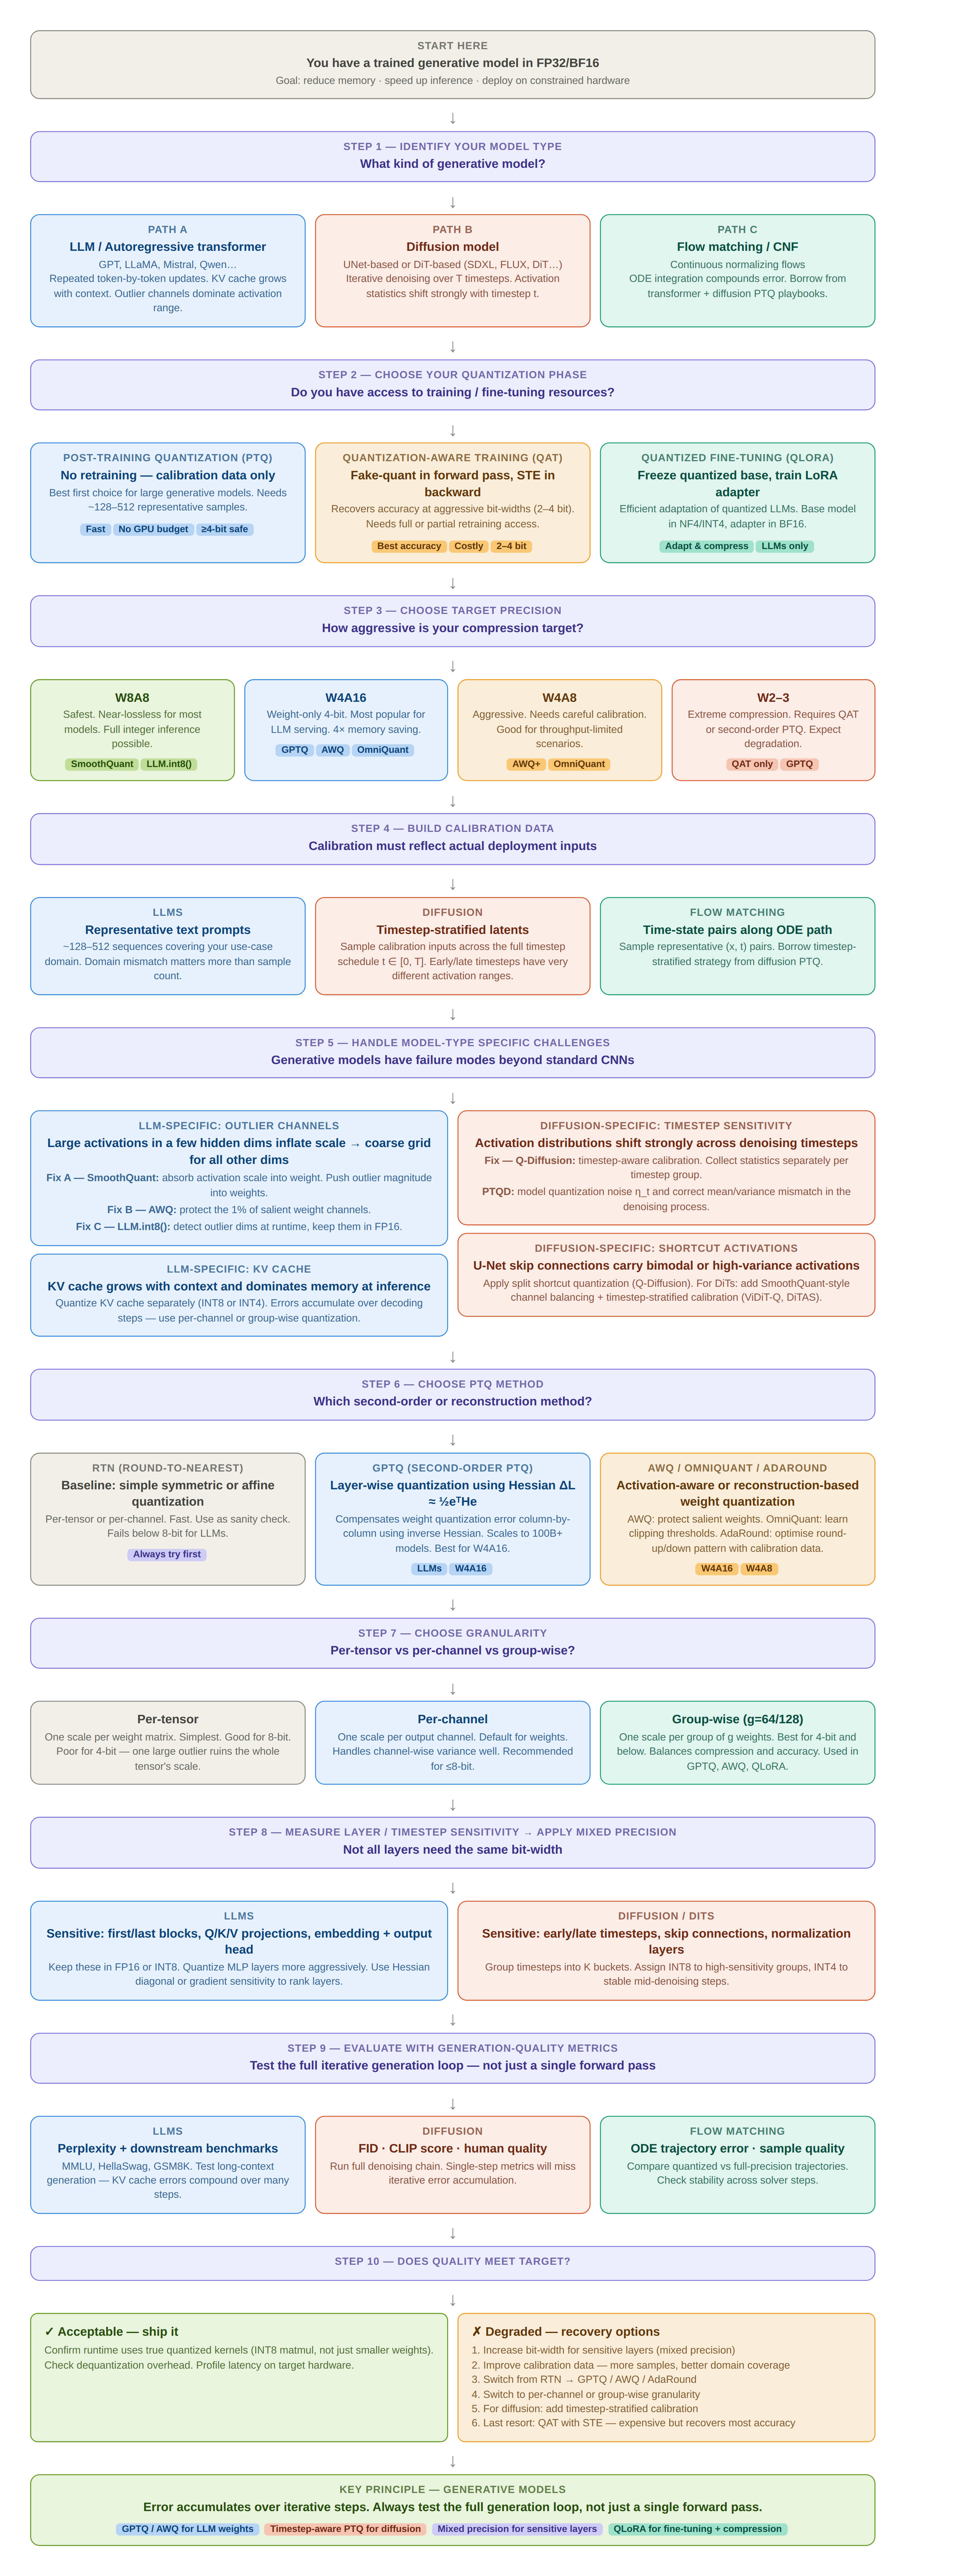

## Use of Generative AI

Portions of this material were developed with the assistance of **generative artificial intelligence tools.  
The author reviewed, edited, and validated all content, including explanations, code, and examples, and assumes full responsibility for accuracy and interpretation.